## RQ2: Fairness Analysis
#### Group 6 | Francesco Biedermann (FB2709) | Brian Hsu (CH4004) | Phoebe Zhao (PYZ2001)
#### APAN5205 Applied Machine Learning 2 | Prof. Andrew Assing

This notebook addresses Research Question 2: Do mortgage approval outcomes and model predictions differ systematically across demographic groups defined by race, ethnicity, and sex?

We conduct five complementary analyses:

- Part A: Raw approval rates by demographic group
- Part B: Model performance metrics segmented by demographic group
- Part C: Interest rate and rate spread fairness among approved applicants
- Part D: Making bias explicit through disparate impact ratios, predicted probability distributions, and feature distributions
- Part E: Association rules identifying which feature combinations drive denial and which demographic groups are disproportionately exposed to them

### Step 1 | Setup and Data Loading
We import required libraries and load the enriched cleaned dataset, which contains the original 32 model features plus five additional columns merged back from the raw HMDA file: interest rate, rate spread, denial reason, tract minority population percentage, and tract to MSA income percentage. Demographic variables are preserved for fairness analysis only and were never used as model features in RQ1.

In [1]:
# Step 1: Setup and Data Loading
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, roc_auc_score
)

from mlxtend.frequent_patterns import apriori, association_rules
from mlxtend.preprocessing import TransactionEncoder

df = pd.read_csv('hmda_2024_cleaned_with_extras.csv')

print('Dataset shape:', df.shape)
print('Approval rate:', round(df['approved'].mean() * 100, 2), '%')
print('Columns:', df.columns.tolist())

Dataset shape: (433173, 37)
Approval rate: 77.36 %
Columns: ['approved', 'loan_type', 'loan_purpose', 'preapproval', 'loan_amount', 'loan_term', 'lien_status', 'construction_method', 'income', 'combined_loan_to_value_ratio', 'applicant_credit_score_type', 'property_value', 'occupancy_type', 'total_units', 'derived_race', 'derived_ethnicity', 'derived_sex', 'balloon_payment', 'interest_only_payment', 'negative_amortization', 'other_nonamortizing_features', 'reverse_mortgage', 'open_end_line_of_credit', 'business_or_commercial_purpose', 'conforming_loan_limit', 'state_code', 'aus_1', 'interest_rate_missing', 'debt_to_income_ratio_missing', 'combined_loan_to_value_ratio_missing', 'dti_ordinal', 'age_ordinal', 'interest_rate', 'rate_spread', 'denial_reason_1', 'tract_minority_population_percent', 'tract_to_msa_income_percentage']


### Step 2 | Reconstruct Feature Matrix and Train-Test Split
We replicate the exact preprocessing pipeline from RQ1 using identical parameters (test_size=0.30, random_state=42, stratify=y) so the test set is identical across both notebooks. Demographic labels and the new fairness columns are preserved separately and never enter the model.

In [2]:
# Step 2: Reconstruct Feature Matrix and Train-Test Split

y = df['approved']

drop_cols = [
    'approved',
    'derived_race',
    'derived_ethnicity',
    'derived_sex',
    'reverse_mortgage',
    'interest_rate_missing',
    'interest_rate',
    'rate_spread',
    'denial_reason_1',
    'tract_minority_population_percent',
    'tract_to_msa_income_percentage'
]

X = df.drop(columns=drop_cols)
X = pd.get_dummies(X, columns=['state_code'], drop_first=True)

print('Feature matrix shape:', X.shape)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.30, random_state=42, stratify=y
)

print('Training set:', X_train.shape[0], 'rows')
print('Test set:    ', X_test.shape[0], 'rows')
print('Approval rate - Train:', round(y_train.mean() * 100, 2), '%')
print('Approval rate - Test: ', round(y_test.mean() * 100, 2), '%')

# Preserve demographic and fairness labels for test set rows
fairness_cols = ['derived_race', 'derived_ethnicity', 'derived_sex',
                 'interest_rate', 'rate_spread', 'denial_reason_1',
                 'tract_minority_population_percent', 'tract_to_msa_income_percentage']

demo_test = df.loc[X_test.index, fairness_cols].copy()
demo_test['approved'] = y_test.values

print('Index alignment check (should be True):', (demo_test.index == X_test.index).all())

Feature matrix shape: (433173, 78)
Training set: 303221 rows
Test set:     129952 rows
Approval rate - Train: 77.36 %
Approval rate - Test:  77.36 %
Index alignment check (should be True): True


### Step 3 | Retrain Best Model from RQ1 (Random Forest)
We retrain the Random Forest model identified as best in RQ1, using identical hyperparameter tuning. The overall test set performance printed below should match RQ1 results exactly.

In [3]:
# Step 3: Retrain Best Random Forest from RQ1

X_tune, _, y_tune, _ = train_test_split(
    X_train, y_train, train_size=50000, random_state=42, stratify=y_train
)

forest = RandomForestClassifier(random_state=42, n_jobs=-1)

param_grid = {
    'n_estimators': [100, 200],
    'max_depth': [5, 10, 15]
}

tune_forest = GridSearchCV(
    estimator=forest,
    param_grid=param_grid,
    scoring='roc_auc',
    cv=5,
    n_jobs=-1
)

tune_forest.fit(X_tune, y_tune)

print('Best parameters:', tune_forest.best_params_)
print('Best CV AUC-ROC:', round(tune_forest.best_score_, 4))

best_forest = tune_forest.best_estimator_
best_forest.fit(X_train, y_train)
print('Random Forest refitted on full training data.')

y_pred = best_forest.predict(X_test)
y_prob = best_forest.predict_proba(X_test)[:, 1]

print('Overall Test Set Performance (cross-check with RQ1):')
print('  Accuracy: ', round(accuracy_score(y_test, y_pred), 4))
print('  Precision:', round(precision_score(y_test, y_pred), 4))
print('  Recall:   ', round(recall_score(y_test, y_pred), 4))
print('  F1-Score: ', round(f1_score(y_test, y_pred), 4))
print('  AUC-ROC:  ', round(roc_auc_score(y_test, y_prob), 4))

demo_test['predicted'] = y_pred
demo_test['predicted_prob'] = y_prob

/opt/anaconda3/lib/python3.13/site-packages/joblib/externals/loky/backend/fork_exec.py:38: DeprecationWarning: This process (pid=95000) is multi-threaded, use of fork() may lead to deadlocks in the child.
  pid = os.fork()
/opt/anaconda3/lib/python3.13/site-packages/joblib/externals/loky/backend/fork_exec.py:38: DeprecationWarning: This process (pid=95000) is multi-threaded, use of fork() may lead to deadlocks in the child.
  pid = os.fork()
/opt/anaconda3/lib/python3.13/site-packages/joblib/externals/loky/backend/fork_exec.py:38: DeprecationWarning: This process (pid=95000) is multi-threaded, use of fork() may lead to deadlocks in the child.
  pid = os.fork()
/opt/anaconda3/lib/python3.13/site-packages/joblib/externals/loky/backend/fork_exec.py:38: DeprecationWarning: This process (pid=95000) is multi-threaded, use of fork() may lead to deadlocks in the child.
  pid = os.fork()
/opt/anaconda3/lib/python3.13/site-packages/joblib/externals/loky/backend/fork_exec.py:38: DeprecationWarnin

Best parameters: {'max_depth': 15, 'n_estimators': 200}
Best CV AUC-ROC: 0.868
Random Forest refitted on full training data.
Overall Test Set Performance (cross-check with RQ1):
  Accuracy:  0.8691
  Precision: 0.8669
  Recall:    0.9815
  F1-Score:  0.9206
  AUC-ROC:   0.8738


---
## Part A: Descriptive Fairness - Raw Approval Rates by Demographic Group

We examine observed approval rates across all three demographic dimensions. Groups with fewer than 200 observations are excluded from visualisations. The overall approval rate serves as the reference line throughout.

### Step 4 | Approval Rates by Race

Approval Rates by Race:
                                           approval_rate_pct       n
derived_race                                                        
2 or more minority races                               63.57    1076
Native Hawaiian or Other Pacific Islander              64.26    1052
Black or African American                              65.66   38042
American Indian or Alaska Native                       65.70    3283
Race Not Available                                     71.56   66364
White                                                  80.05  285557
Asian                                                  80.24   27731
Joint                                                  82.61    9937
Overall approval rate: 77.36%


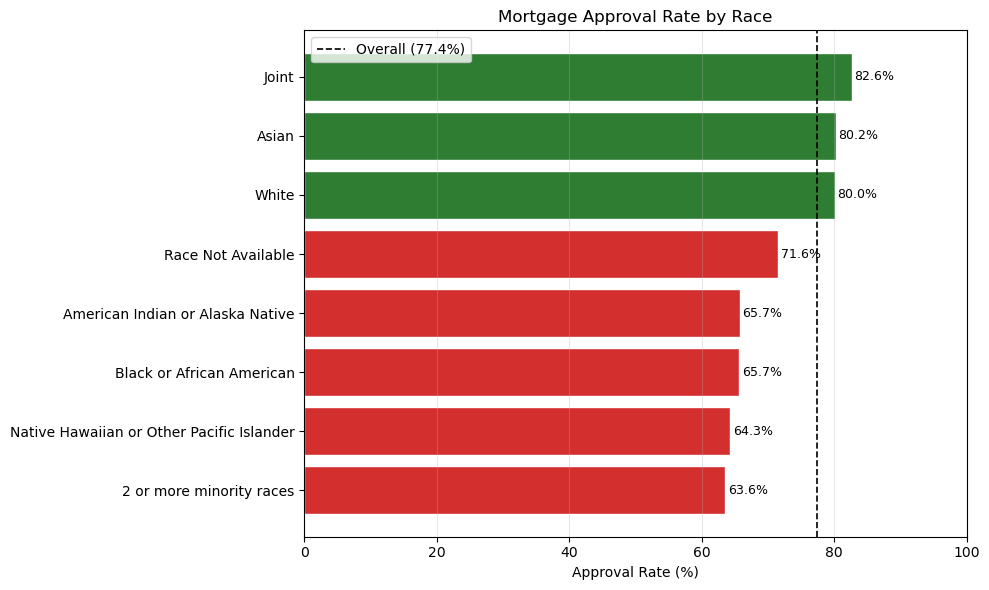

In [4]:
# Step 4: Approval Rates by Race

EXCLUDE_SMALL = ['Free Form Text Only']
overall_rate = df['approved'].mean()

race_stats = (
    df[~df['derived_race'].isin(EXCLUDE_SMALL)]
    .groupby('derived_race')['approved']
    .agg(['mean', 'count'])
    .rename(columns={'mean': 'approval_rate', 'count': 'n'})
    .sort_values('approval_rate', ascending=True)
)
race_stats['approval_rate_pct'] = (race_stats['approval_rate'] * 100).round(2)

print('Approval Rates by Race:')
print(race_stats[['approval_rate_pct', 'n']].to_string())
print(f'Overall approval rate: {round(overall_rate * 100, 2)}%')

colors = ['#d32f2f' if r < overall_rate else '#2e7d32' for r in race_stats['approval_rate']]

fig, ax = plt.subplots(figsize=(10, 6))
bars = ax.barh(race_stats.index, race_stats['approval_rate_pct'], color=colors, edgecolor='white')
ax.axvline(overall_rate * 100, color='black', linewidth=1.2, linestyle='--',
           label=f'Overall ({round(overall_rate * 100, 1)}%)')

for bar, val in zip(bars, race_stats['approval_rate_pct']):
    ax.text(val + 0.4, bar.get_y() + bar.get_height() / 2,
            f'{val:.1f}%', va='center', fontsize=9)

ax.set_xlabel('Approval Rate (%)')
ax.set_title('Mortgage Approval Rate by Race')
ax.set_xlim(0, 100)
ax.legend()
ax.grid(alpha=0.3, axis='x')
plt.tight_layout()
plt.show()

### Step 5 | Approval Rates by Ethnicity

Approval Rates by Ethnicity:
                         approval_rate_pct       n
derived_ethnicity                                 
Hispanic or Latino                   71.88   54740
Ethnicity Not Available              72.09   60305
Not Hispanic or Latino               79.24  306304
Joint                                81.35   11643


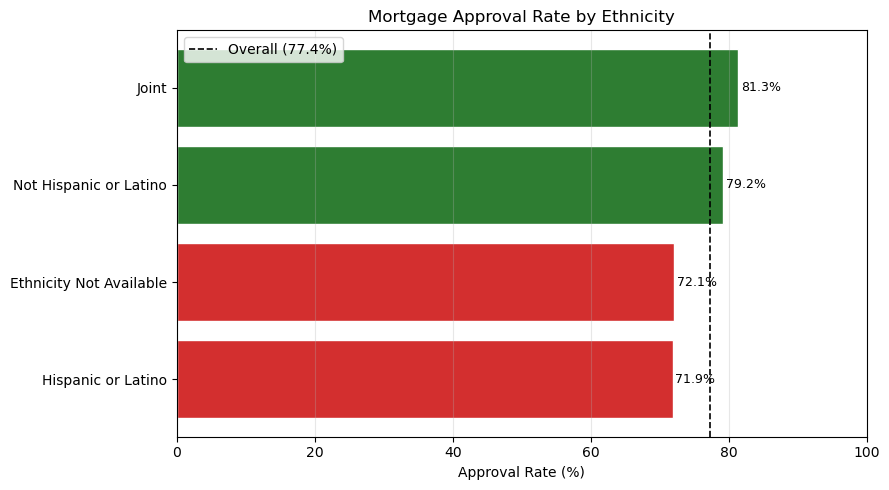

In [5]:
# Step 5: Approval Rates by Ethnicity

eth_stats = (
    df[~df['derived_ethnicity'].isin(EXCLUDE_SMALL)]
    .groupby('derived_ethnicity')['approved']
    .agg(['mean', 'count'])
    .rename(columns={'mean': 'approval_rate', 'count': 'n'})
    .sort_values('approval_rate', ascending=True)
)
eth_stats['approval_rate_pct'] = (eth_stats['approval_rate'] * 100).round(2)

print('Approval Rates by Ethnicity:')
print(eth_stats[['approval_rate_pct', 'n']].to_string())

colors = ['#d32f2f' if r < overall_rate else '#2e7d32' for r in eth_stats['approval_rate']]

fig, ax = plt.subplots(figsize=(9, 5))
bars = ax.barh(eth_stats.index, eth_stats['approval_rate_pct'], color=colors, edgecolor='white')
ax.axvline(overall_rate * 100, color='black', linewidth=1.2, linestyle='--',
           label=f'Overall ({round(overall_rate * 100, 1)}%)')

for bar, val in zip(bars, eth_stats['approval_rate_pct']):
    ax.text(val + 0.4, bar.get_y() + bar.get_height() / 2,
            f'{val:.1f}%', va='center', fontsize=9)

ax.set_xlabel('Approval Rate (%)')
ax.set_title('Mortgage Approval Rate by Ethnicity')
ax.set_xlim(0, 100)
ax.legend()
ax.grid(alpha=0.3, axis='x')
plt.tight_layout()
plt.show()

### Step 6 | Approval Rates by Sex

Approval Rates by Sex:
                   approval_rate_pct       n
derived_sex                                 
Sex Not Available              69.73   27889
Female                         73.13   99771
Male                           75.51  150001
Joint                          83.22  155512


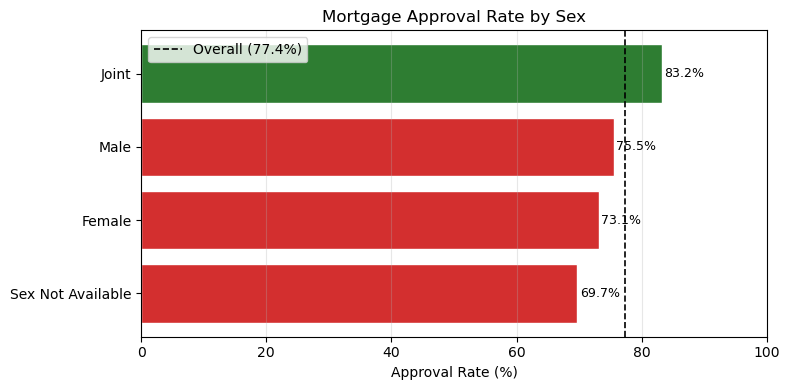

In [6]:
# Step 6: Approval Rates by Sex

sex_stats = (
    df.groupby('derived_sex')['approved']
    .agg(['mean', 'count'])
    .rename(columns={'mean': 'approval_rate', 'count': 'n'})
    .sort_values('approval_rate', ascending=True)
)
sex_stats['approval_rate_pct'] = (sex_stats['approval_rate'] * 100).round(2)

print('Approval Rates by Sex:')
print(sex_stats[['approval_rate_pct', 'n']].to_string())

colors = ['#d32f2f' if r < overall_rate else '#2e7d32' for r in sex_stats['approval_rate']]

fig, ax = plt.subplots(figsize=(8, 4))
bars = ax.barh(sex_stats.index, sex_stats['approval_rate_pct'], color=colors, edgecolor='white')
ax.axvline(overall_rate * 100, color='black', linewidth=1.2, linestyle='--',
           label=f'Overall ({round(overall_rate * 100, 1)}%)')

for bar, val in zip(bars, sex_stats['approval_rate_pct']):
    ax.text(val + 0.4, bar.get_y() + bar.get_height() / 2,
            f'{val:.1f}%', va='center', fontsize=9)

ax.set_xlabel('Approval Rate (%)')
ax.set_title('Mortgage Approval Rate by Sex')
ax.set_xlim(0, 100)
ax.legend()
ax.grid(alpha=0.3, axis='x')
plt.tight_layout()
plt.show()

### Step 7 | Approval Rate Gap Summary
We compute each group's gap versus the overall rate and display all dimensions together in a single diverging chart.

Approval Rate Gap vs Overall (percentage points):
                                           Dimension  approval_rate_pct       n  gap_vs_overall_pp
2 or more minority races                        Race              63.57    1076             -13.79
Native Hawaiian or Other Pacific Islander       Race              64.26    1052             -13.10
Black or African American                       Race              65.66   38042             -11.70
American Indian or Alaska Native                Race              65.70    3283             -11.66
Sex Not Available                                Sex              69.73   27889              -7.63
Race Not Available                              Race              71.56   66364              -5.80
Hispanic or Latino                         Ethnicity              71.88   54740              -5.48
Ethnicity Not Available                    Ethnicity              72.09   60305              -5.27
Female                                           Sex       

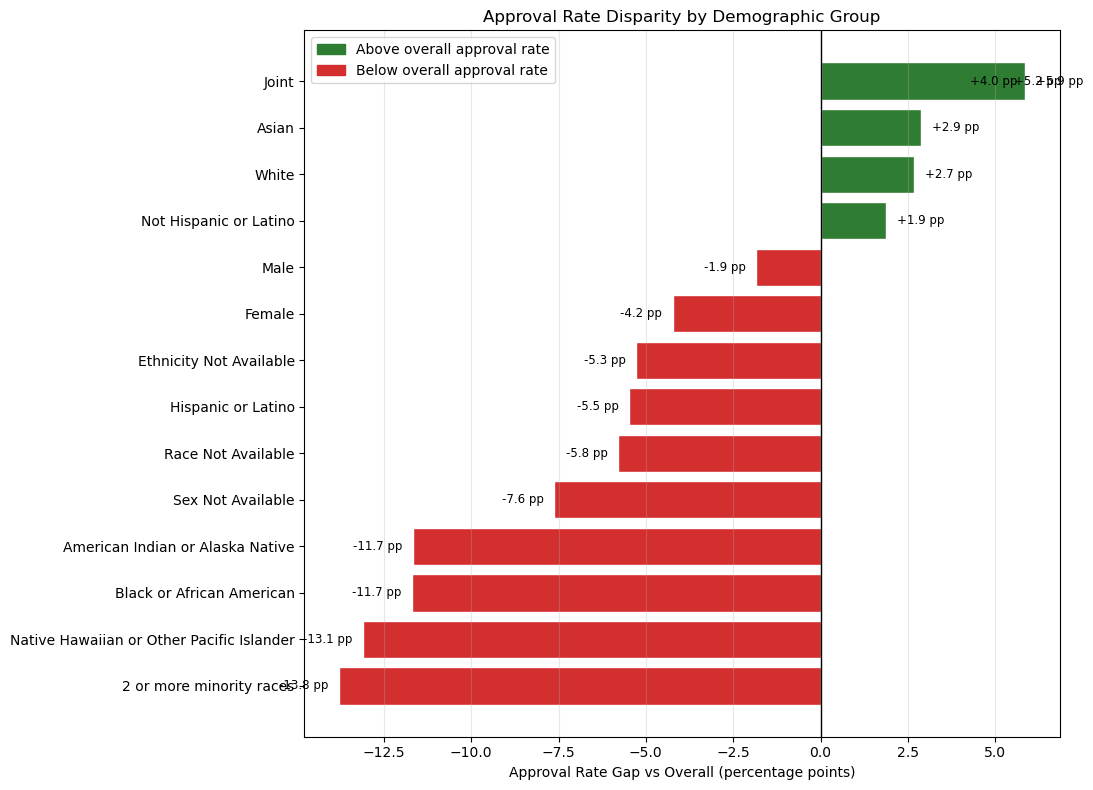

In [7]:
# Step 7: Approval Rate Gap Summary

def gap_table(stats_df, dimension_label):
    t = stats_df[['approval_rate_pct', 'n']].copy()
    t['gap_vs_overall_pp'] = (t['approval_rate_pct'] - round(overall_rate * 100, 2)).round(2)
    t.insert(0, 'Dimension', dimension_label)
    return t

gap_summary = pd.concat([
    gap_table(race_stats, 'Race'),
    gap_table(eth_stats,  'Ethnicity'),
    gap_table(sex_stats,  'Sex')
]).sort_values('gap_vs_overall_pp')

print('Approval Rate Gap vs Overall (percentage points):')
print(gap_summary.to_string())

fig, ax = plt.subplots(figsize=(11, 8))
colors = ['#d32f2f' if g < 0 else '#2e7d32' for g in gap_summary['gap_vs_overall_pp']]
bars = ax.barh(gap_summary.index, gap_summary['gap_vs_overall_pp'], color=colors, edgecolor='white')

for bar, val in zip(bars, gap_summary['gap_vs_overall_pp']):
    offset = 0.3 if val >= 0 else -0.3
    ha = 'left' if val >= 0 else 'right'
    ax.text(val + offset, bar.get_y() + bar.get_height() / 2,
            f'{val:+.1f} pp', va='center', ha=ha, fontsize=8.5)

ax.axvline(0, color='black', linewidth=1)
ax.set_xlabel('Approval Rate Gap vs Overall (percentage points)')
ax.set_title('Approval Rate Disparity by Demographic Group')
ax.grid(alpha=0.3, axis='x')

red_patch   = mpatches.Patch(color='#d32f2f', label='Below overall approval rate')
green_patch = mpatches.Patch(color='#2e7d32', label='Above overall approval rate')
ax.legend(handles=[green_patch, red_patch])
plt.tight_layout()
plt.show()

### Step 7b | Statistical Significance Testing for Approval Rate Gaps
Descriptive statistics alone do not confirm that the observed approval rate gaps are statistically reliable. With 433,000 observations, even tiny differences can be significant, but we should formally verify the gaps that matter most.

We use two complementary tests. The chi-square test checks whether the distribution of approvals and denials across racial groups differs from what would be expected under independence. The two-proportion z-test then quantifies the significance of specific pairwise gaps, comparing each minority group directly against White applicants as the reference group. A p-value below 0.05 indicates the gap is statistically significant.

=== Chi-Square Test: Approval Outcomes vs Race ===
Chi-square statistic: 4,589.72
Degrees of freedom:   4
P-value:              0.00e+00
Result: Significant at the 0.05 level

=== Two-Proportion Z-Test: Each Group vs White Applicants ===
Reference group (White): n=285,557, approval rate=80.05%

                                               N  Approval Rate (%)  Gap vs White (pp)  Z-statistic   P-value Significant
Group                                                                                                                    
Black or African American                  38042              65.66             -14.39      -64.036  0.00e+00         Yes
Asian                                      27731              80.24               0.18        0.732  4.64e-01          No
American Indian or Alaska Native            3283              65.70             -14.35      -20.394  0.00e+00         Yes
Native Hawaiian or Other Pacific Islander   1052              64.26             -15.79      -1

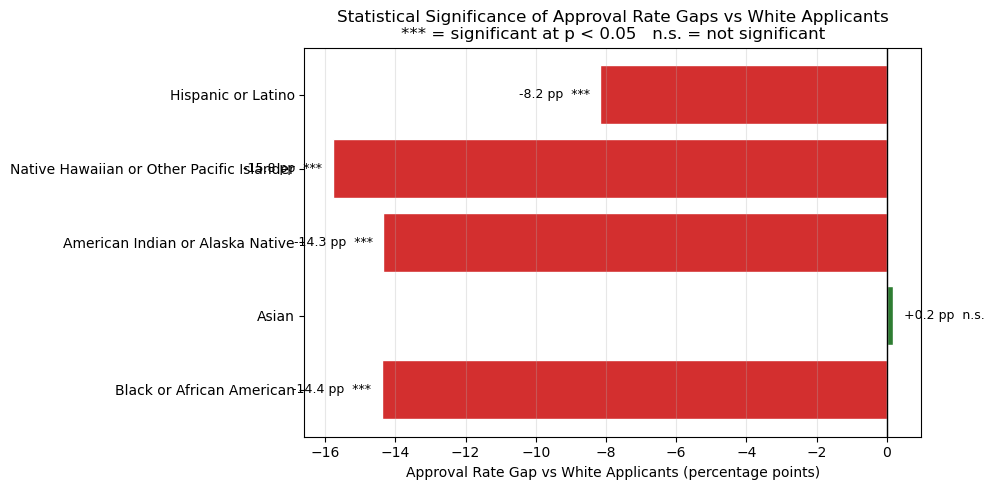


=== Two-Proportion Z-Test: Ethnicity (Hispanic vs Not Hispanic) ===
Hispanic approval rate:     71.88%  (n=54,740)
Not Hispanic approval rate: 79.24%  (n=306,304)
Gap: -7.36 pp
Z-statistic: -38.359,  P-value: 0.00e+00
Result: Significant at the 0.05 level

=== Two-Proportion Z-Test: Sex (Female vs Male) ===
Female approval rate: 73.13%  (n=99,771)
Male approval rate:   75.51%  (n=150,001)
Gap: -2.38 pp
Z-statistic: -13.38,  P-value: 0.00e+00
Result: Significant at the 0.05 level


In [8]:
# Step 7b: Statistical Significance Testing

from scipy import stats
from scipy.stats import chi2_contingency

# ── Test 1: Chi-square test across all racial groups ──
# Tests whether approval outcomes are independent of race overall

RACE_TEST_GROUPS = ['White', 'Black or African American', 'Asian',
                    'American Indian or Alaska Native',
                    'Native Hawaiian or Other Pacific Islander']

df_race_test = df[df['derived_race'].isin(RACE_TEST_GROUPS)].copy()

contingency_race = pd.crosstab(df_race_test['derived_race'], df_race_test['approved'])
chi2, p_chi2, dof, expected = chi2_contingency(contingency_race)

print('=== Chi-Square Test: Approval Outcomes vs Race ===')
print(f'Chi-square statistic: {chi2:,.2f}')
print(f'Degrees of freedom:   {dof}')
print(f'P-value:              {p_chi2:.2e}')
print(f'Result: {"Significant" if p_chi2 < 0.05 else "Not significant"} at the 0.05 level')
print()

# ── Test 2: Two-proportion z-test for each group vs White ──
# Tests whether each group's approval rate differs significantly from White applicants

white_data = df[df['derived_race'] == 'White']['approved']
n_white    = len(white_data)
p_white    = white_data.mean()

print('=== Two-Proportion Z-Test: Each Group vs White Applicants ===')
print(f'Reference group (White): n={n_white:,}, approval rate={round(p_white*100,2)}%')
print()

rows = []
for race in ['Black or African American', 'Asian',
             'American Indian or Alaska Native',
             'Native Hawaiian or Other Pacific Islander',
             'Hispanic or Latino']:

    if race in df['derived_race'].values:
        group_data = df[df['derived_race'] == race]['approved']
        col = 'derived_race'
    else:
        group_data = df[df['derived_ethnicity'] == race]['approved']
        col = 'derived_ethnicity'

    n_group = len(group_data)
    p_group = group_data.mean()

    # Pooled proportion
    p_pool = (p_white * n_white + p_group * n_group) / (n_white + n_group)
    se     = np.sqrt(p_pool * (1 - p_pool) * (1/n_white + 1/n_group))
    z      = (p_group - p_white) / se
    p_val  = 2 * (1 - stats.norm.cdf(abs(z)))

    gap_pp = round((p_group - p_white) * 100, 2)

    rows.append({
        'Group': race,
        'N': n_group,
        'Approval Rate (%)': round(p_group * 100, 2),
        'Gap vs White (pp)': gap_pp,
        'Z-statistic': round(z, 3),
        'P-value': f'{p_val:.2e}',
        'Significant': 'Yes' if p_val < 0.05 else 'No'
    })

sig_df = pd.DataFrame(rows).set_index('Group')
print(sig_df.to_string())

# ── Visualise: gap with significance annotation ──
fig, ax = plt.subplots(figsize=(10, 5))

colors = ['#d32f2f' if g < 0 else '#2e7d32' for g in sig_df['Gap vs White (pp)']]
bars = ax.barh(sig_df.index, sig_df['Gap vs White (pp)'], color=colors, edgecolor='white')

for bar, (idx, row) in zip(bars, sig_df.iterrows()):
    val  = row['Gap vs White (pp)']
    sig  = '***' if row['Significant'] == 'Yes' else 'n.s.'
    offset = 0.3 if val >= 0 else -0.3
    ha     = 'left' if val >= 0 else 'right'
    ax.text(val + offset, bar.get_y() + bar.get_height() / 2,
            f'{val:+.1f} pp  {sig}', va='center', ha=ha, fontsize=9)

ax.axvline(0, color='black', linewidth=1)
ax.set_xlabel('Approval Rate Gap vs White Applicants (percentage points)')
ax.set_title('Statistical Significance of Approval Rate Gaps vs White Applicants\n'
             '*** = significant at p < 0.05   n.s. = not significant')
ax.grid(alpha=0.3, axis='x')
plt.tight_layout()
plt.show()

# ── Ethnicity and sex significance ──
print()
print('=== Two-Proportion Z-Test: Ethnicity (Hispanic vs Not Hispanic) ===')
hisp     = df[df['derived_ethnicity'] == 'Hispanic or Latino']['approved']
not_hisp = df[df['derived_ethnicity'] == 'Not Hispanic or Latino']['approved']

p_pool_e = (hisp.sum() + not_hisp.sum()) / (len(hisp) + len(not_hisp))
se_e     = np.sqrt(p_pool_e * (1 - p_pool_e) * (1/len(hisp) + 1/len(not_hisp)))
z_e      = (hisp.mean() - not_hisp.mean()) / se_e
p_e      = 2 * (1 - stats.norm.cdf(abs(z_e)))

print(f'Hispanic approval rate:     {round(hisp.mean()*100,2)}%  (n={len(hisp):,})')
print(f'Not Hispanic approval rate: {round(not_hisp.mean()*100,2)}%  (n={len(not_hisp):,})')
print(f'Gap: {round((hisp.mean()-not_hisp.mean())*100,2)} pp')
print(f'Z-statistic: {round(z_e,3)},  P-value: {p_e:.2e}')
print(f'Result: {"Significant" if p_e < 0.05 else "Not significant"} at the 0.05 level')

print()
print('=== Two-Proportion Z-Test: Sex (Female vs Male) ===')
female = df[df['derived_sex'] == 'Female']['approved']
male   = df[df['derived_sex'] == 'Male']['approved']

p_pool_s = (female.sum() + male.sum()) / (len(female) + len(male))
se_s     = np.sqrt(p_pool_s * (1 - p_pool_s) * (1/len(female) + 1/len(male)))
z_s      = (female.mean() - male.mean()) / se_s
p_s      = 2 * (1 - stats.norm.cdf(abs(z_s)))

print(f'Female approval rate: {round(female.mean()*100,2)}%  (n={len(female):,})')
print(f'Male approval rate:   {round(male.mean()*100,2)}%  (n={len(male):,})')
print(f'Gap: {round((female.mean()-male.mean())*100,2)} pp')
print(f'Z-statistic: {round(z_s,3)},  P-value: {p_s:.2e}')
print(f'Result: {"Significant" if p_s < 0.05 else "Not significant"} at the 0.05 level')

---
## Part B: Model Fairness - Prediction Performance Across Demographic Groups

We evaluate the Random Forest model on the test set segmented by demographic group. Even though demographic variables were excluded from the model, disparities can emerge through proxy discrimination, where features correlated with demographics carry the signal. Recall is the most fairness-critical metric in lending: low recall for a group means the model systematically denies applicants from that group who should have been approved.

### Step 8 | Helper Function: Per-Group Metrics

In [9]:
# Step 8: Per-Group Fairness Metrics Helper

MIN_GROUP_SIZE = 200

def fairness_metrics(demo_df, group_col, exclude_groups=None):
    if exclude_groups is None:
        exclude_groups = []
    rows = []
    for group, subset in demo_df.groupby(group_col):
        if group in exclude_groups or len(subset) < MIN_GROUP_SIZE:
            continue
        y_true = subset['approved']
        y_pred = subset['predicted']
        y_prob = subset['predicted_prob']
        auc = roc_auc_score(y_true, y_prob) if len(y_true.unique()) == 2 else np.nan
        rows.append({
            'Group': group,
            'N': len(subset),
            'Actual Approval Rate (%)':    round(y_true.mean() * 100, 2),
            'Predicted Approval Rate (%)': round(y_pred.mean() * 100, 2),
            'Accuracy':  round(accuracy_score(y_true, y_pred), 4),
            'Precision': round(precision_score(y_true, y_pred, zero_division=0), 4),
            'Recall':    round(recall_score(y_true, y_pred, zero_division=0), 4),
            'F1-Score':  round(f1_score(y_true, y_pred, zero_division=0), 4),
            'AUC-ROC':   round(auc, 4) if not np.isnan(auc) else np.nan
        })
    return pd.DataFrame(rows).set_index('Group')

metric_cols = ['Accuracy', 'Precision', 'Recall', 'F1-Score', 'AUC-ROC']
width = 0.35

print(f'Groups with fewer than {MIN_GROUP_SIZE} test-set observations will be excluded.')

Groups with fewer than 200 test-set observations will be excluded.


### Step 9 | Model Fairness by Race

Model Performance by Race (test set):
                                               N  Actual Approval Rate (%)  Predicted Approval Rate (%)  Accuracy  Precision  Recall  F1-Score  AUC-ROC
Group                                                                                                                                                  
2 or more minority races                     326                     67.48                        79.14    0.8282     0.8178  0.9591    0.8828   0.8847
American Indian or Alaska Native            1014                     65.68                        77.61    0.8294     0.8132  0.9610    0.8809   0.8920
Asian                                       8307                     80.21                        89.80    0.8874     0.8839  0.9896    0.9338   0.8892
Black or African American                  11278                     65.82                        81.34    0.8119     0.7890  0.9751    0.8722   0.8627
Joint                                       3027  

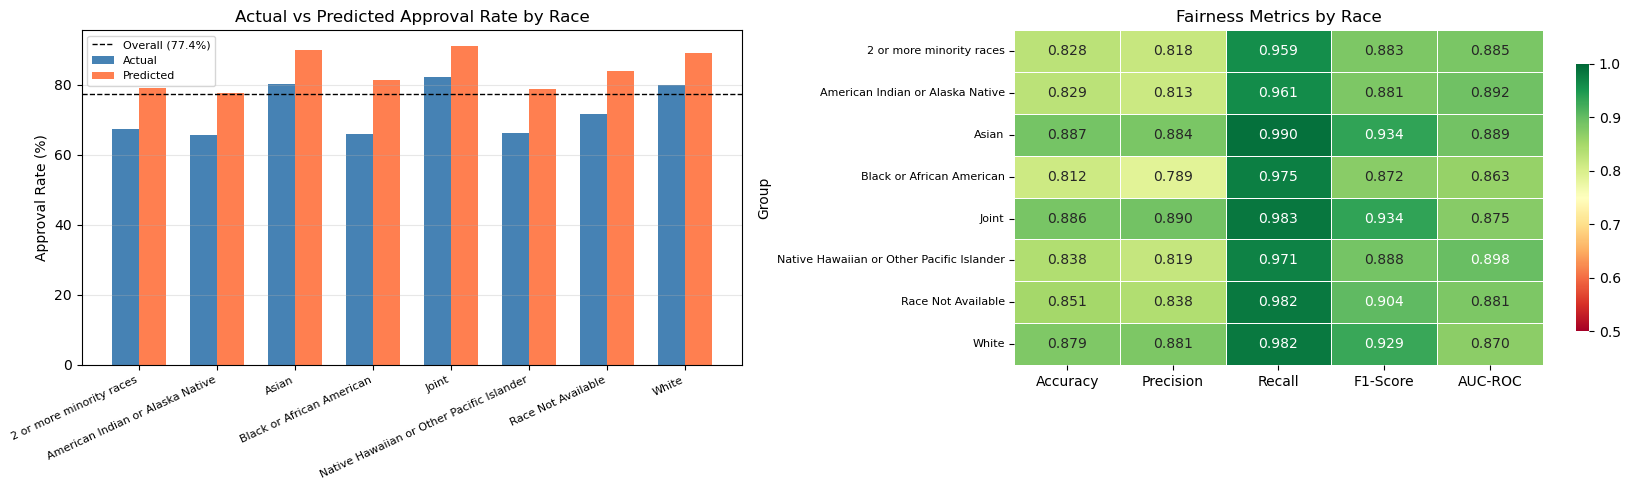

In [10]:
# Step 9: Model Fairness by Race

race_metrics = fairness_metrics(demo_test, 'derived_race', exclude_groups=['Free Form Text Only'])

print('Model Performance by Race (test set):')
print(race_metrics.to_string())

fig, axes = plt.subplots(1, 2, figsize=(17, 5))

ax = axes[0]
x = np.arange(len(race_metrics))
ax.bar(x - width/2, race_metrics['Actual Approval Rate (%)'],    width, label='Actual',    color='steelblue')
ax.bar(x + width/2, race_metrics['Predicted Approval Rate (%)'], width, label='Predicted', color='coral')
ax.axhline(overall_rate * 100, color='black', linewidth=1, linestyle='--',
           label=f'Overall ({round(overall_rate * 100, 1)}%)')
ax.set_xticks(x)
ax.set_xticklabels(race_metrics.index, rotation=25, ha='right', fontsize=8)
ax.set_ylabel('Approval Rate (%)')
ax.set_title('Actual vs Predicted Approval Rate by Race')
ax.legend(fontsize=8)
ax.grid(alpha=0.3, axis='y')

ax2 = axes[1]
sns.heatmap(race_metrics[metric_cols], annot=True, fmt='.3f',
            cmap='RdYlGn', vmin=0.5, vmax=1.0, ax=ax2,
            linewidths=0.5, cbar_kws={'shrink': 0.8})
ax2.set_title('Fairness Metrics by Race')
ax2.set_yticklabels(ax2.get_yticklabels(), rotation=0, fontsize=8)
plt.tight_layout()
plt.show()

### Step 10 | Model Fairness by Ethnicity

Model Performance by Ethnicity (test set):
                             N  Actual Approval Rate (%)  Predicted Approval Rate (%)  Accuracy  Precision  Recall  F1-Score  AUC-ROC
Group                                                                                                                                
Ethnicity Not Available  18069                     72.37                        84.08    0.8557     0.8446  0.9812    0.9078   0.8820
Hispanic or Latino       16432                     71.98                        83.31    0.8480     0.8408  0.9731    0.9021   0.8753
Joint                     3518                     81.47                        89.88    0.8880     0.8909  0.9829    0.9346   0.8797
Not Hispanic or Latino   91874                     79.17                        88.97    0.8749     0.8746  0.9829    0.9256   0.8709


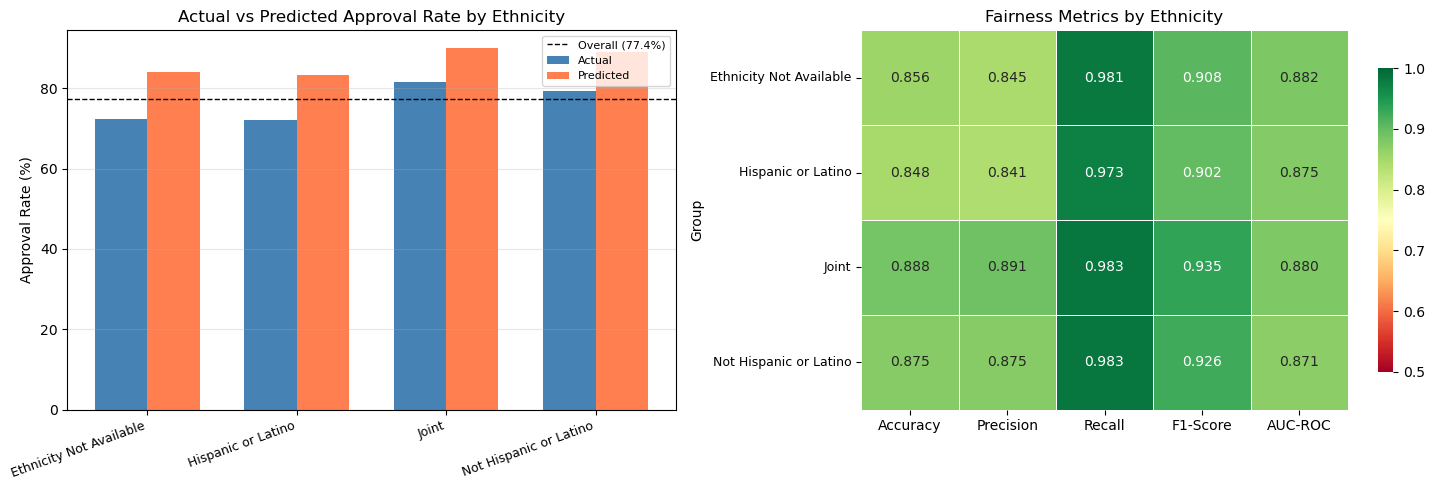

In [11]:
# Step 10: Model Fairness by Ethnicity

eth_metrics = fairness_metrics(demo_test, 'derived_ethnicity', exclude_groups=['Free Form Text Only'])

print('Model Performance by Ethnicity (test set):')
print(eth_metrics.to_string())

fig, axes = plt.subplots(1, 2, figsize=(15, 5))

ax = axes[0]
x = np.arange(len(eth_metrics))
ax.bar(x - width/2, eth_metrics['Actual Approval Rate (%)'],    width, label='Actual',    color='steelblue')
ax.bar(x + width/2, eth_metrics['Predicted Approval Rate (%)'], width, label='Predicted', color='coral')
ax.axhline(overall_rate * 100, color='black', linewidth=1, linestyle='--',
           label=f'Overall ({round(overall_rate * 100, 1)}%)')
ax.set_xticks(x)
ax.set_xticklabels(eth_metrics.index, rotation=20, ha='right', fontsize=9)
ax.set_ylabel('Approval Rate (%)')
ax.set_title('Actual vs Predicted Approval Rate by Ethnicity')
ax.legend(fontsize=8)
ax.grid(alpha=0.3, axis='y')

ax2 = axes[1]
sns.heatmap(eth_metrics[metric_cols], annot=True, fmt='.3f',
            cmap='RdYlGn', vmin=0.5, vmax=1.0, ax=ax2,
            linewidths=0.5, cbar_kws={'shrink': 0.8})
ax2.set_title('Fairness Metrics by Ethnicity')
ax2.set_yticklabels(ax2.get_yticklabels(), rotation=0, fontsize=9)
plt.tight_layout()
plt.show()

### Step 11 | Model Fairness by Sex

Model Performance by Sex (test set):
                       N  Actual Approval Rate (%)  Predicted Approval Rate (%)  Accuracy  Precision  Recall  F1-Score  AUC-ROC
Group                                                                                                                          
Female             29915                     73.24                        84.10    0.8583     0.8511  0.9774    0.9099   0.8781
Joint              46723                     83.17                        91.39    0.8899     0.8948  0.9832    0.9369   0.8642
Male               44942                     75.46                        86.86    0.8580     0.8526  0.9814    0.9125   0.8712
Sex Not Available   8372                     69.80                        82.75    0.8514     0.8320  0.9863    0.9026   0.8831


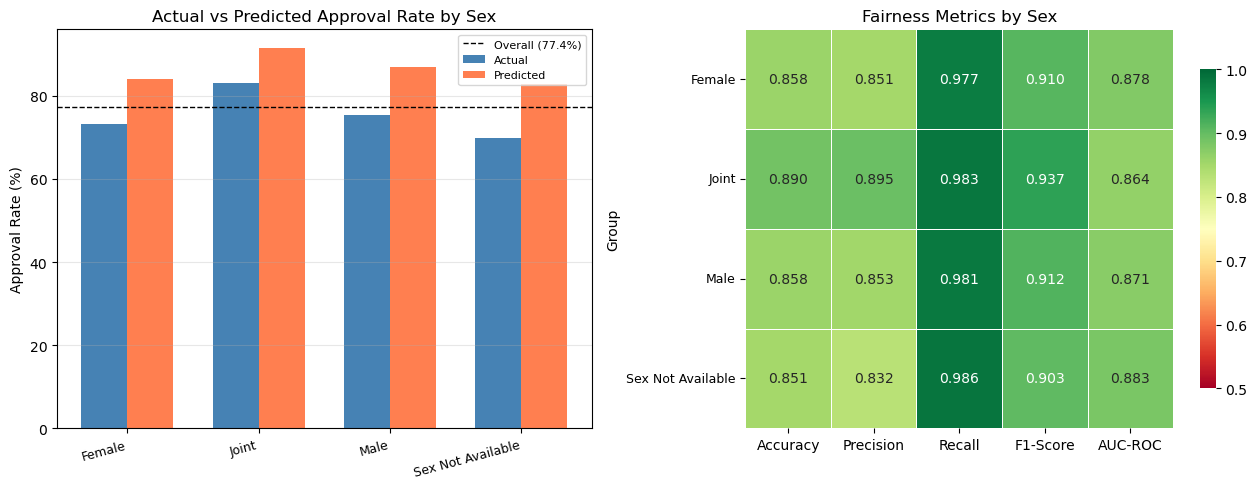

In [12]:
# Step 11: Model Fairness by Sex

sex_metrics = fairness_metrics(demo_test, 'derived_sex')

print('Model Performance by Sex (test set):')
print(sex_metrics.to_string())

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

ax = axes[0]
x = np.arange(len(sex_metrics))
ax.bar(x - width/2, sex_metrics['Actual Approval Rate (%)'],    width, label='Actual',    color='steelblue')
ax.bar(x + width/2, sex_metrics['Predicted Approval Rate (%)'], width, label='Predicted', color='coral')
ax.axhline(overall_rate * 100, color='black', linewidth=1, linestyle='--',
           label=f'Overall ({round(overall_rate * 100, 1)}%)')
ax.set_xticks(x)
ax.set_xticklabels(sex_metrics.index, rotation=15, ha='right', fontsize=9)
ax.set_ylabel('Approval Rate (%)')
ax.set_title('Actual vs Predicted Approval Rate by Sex')
ax.legend(fontsize=8)
ax.grid(alpha=0.3, axis='y')

ax2 = axes[1]
sns.heatmap(sex_metrics[metric_cols], annot=True, fmt='.3f',
            cmap='RdYlGn', vmin=0.5, vmax=1.0, ax=ax2,
            linewidths=0.5, cbar_kws={'shrink': 0.8})
ax2.set_title('Fairness Metrics by Sex')
ax2.set_yticklabels(ax2.get_yticklabels(), rotation=0, fontsize=9)
plt.tight_layout()
plt.show()

### Step 12 | Combined Fairness Summary and Recall Gap Chart

Combined Fairness Metrics:
                                           Dimension      N  Actual Approval Rate (%)  Predicted Approval Rate (%)  Accuracy  Precision  Recall  F1-Score  AUC-ROC
Group                                                                                                                                                             
2 or more minority races                        Race    326                     67.48                        79.14    0.8282     0.8178  0.9591    0.8828   0.8847
American Indian or Alaska Native                Race   1014                     65.68                        77.61    0.8294     0.8132  0.9610    0.8809   0.8920
Native Hawaiian or Other Pacific Islander       Race    315                     66.35                        78.73    0.8381     0.8185  0.9713    0.8884   0.8982
Hispanic or Latino                         Ethnicity  16432                     71.98                        83.31    0.8480     0.8408  0.9731    0.9021   0.

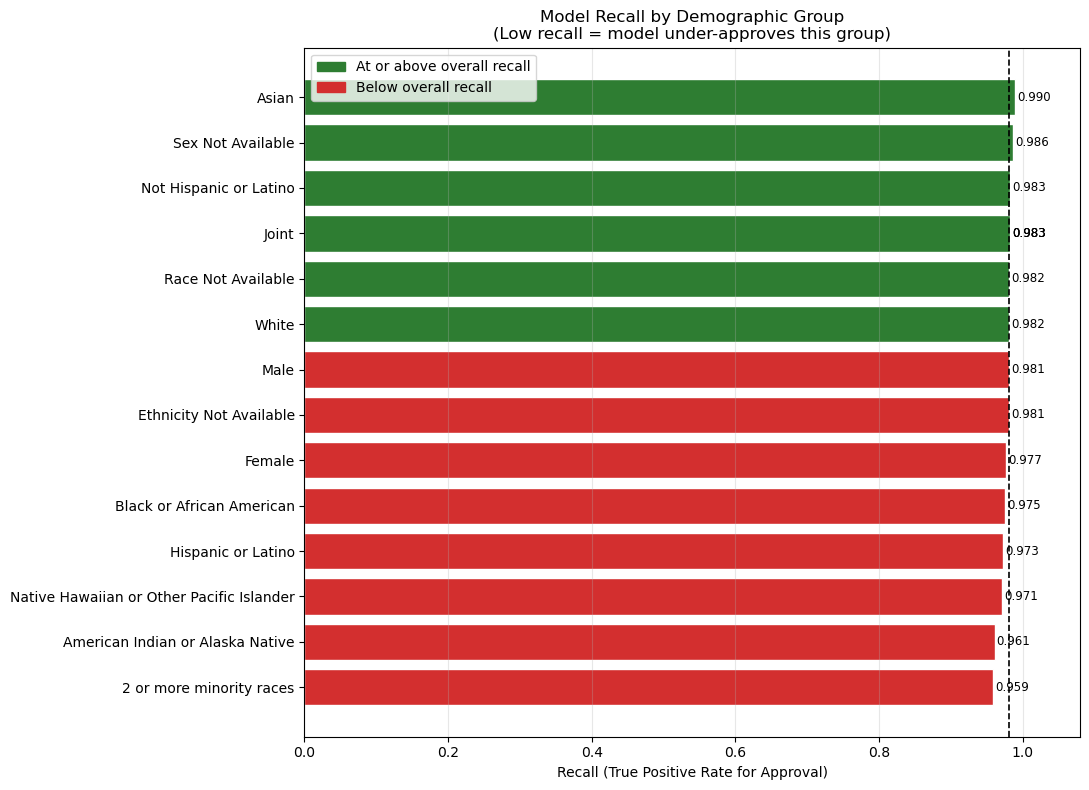

In [13]:
# Step 12: Combined Fairness Summary

def add_dimension(df, label):
    d = df.copy()
    d.insert(0, 'Dimension', label)
    return d

combined = pd.concat([
    add_dimension(race_metrics, 'Race'),
    add_dimension(eth_metrics,  'Ethnicity'),
    add_dimension(sex_metrics,  'Sex')
])

print('Combined Fairness Metrics:')
print(combined.sort_values('Recall').to_string())

overall_recall = recall_score(demo_test['approved'], demo_test['predicted'])
recall_vals = combined['Recall'].sort_values()
colors = ['#d32f2f' if r < overall_recall else '#2e7d32' for r in recall_vals]

fig, ax = plt.subplots(figsize=(11, 8))
bars = ax.barh(recall_vals.index, recall_vals, color=colors, edgecolor='white')
ax.axvline(overall_recall, color='black', linewidth=1.2, linestyle='--',
           label=f'Overall Recall ({round(overall_recall, 3)})')

for bar, val in zip(bars, recall_vals):
    ax.text(val + 0.003, bar.get_y() + bar.get_height() / 2,
            f'{val:.3f}', va='center', fontsize=8.5)

ax.set_xlabel('Recall (True Positive Rate for Approval)')
ax.set_title('Model Recall by Demographic Group\n(Low recall = model under-approves this group)')
ax.set_xlim(0, 1.08)
ax.grid(alpha=0.3, axis='x')

red_patch   = mpatches.Patch(color='#d32f2f', label='Below overall recall')
green_patch = mpatches.Patch(color='#2e7d32', label='At or above overall recall')
ax.legend(handles=[green_patch, red_patch])
plt.tight_layout()
plt.show()

---
## Part C: Interest Rate and Rate Spread Fairness

Among approved applicants only, we examine whether certain demographic groups receive systematically higher interest rates or rate spreads. This captures pricing discrimination, which is distinct from access discrimination measured in Parts A and B.

Rate spread (the difference between a loan's rate and a benchmark rate) is a better fairness measure than the raw interest rate because it controls for variation in loan type and market conditions. A high rate spread flags loans that are expensive relative to comparable products.

### Step 13 | Interest Rate Distribution by Race

Approved applicants with recorded interest rate: 334,369
Overall median interest rate: 6.875%
Overall mean interest rate:   7.147%

Interest Rate by Race (Approved Applicants Only):
                                                n    mean  median     std    p25    p75
derived_race                                                                           
Asian                                       22222  6.8501   6.625  1.4616  6.125  7.340
American Indian or Alaska Native             2151  7.1146   6.750  2.0362  6.125  7.875
Black or African American                   24892  7.0176   6.750  2.0119  6.125  7.625
Native Hawaiian or Other Pacific Islander     675  7.2843   6.875  2.0219  6.250  8.322
White                                      228141  7.1944   6.875  1.7064  6.339  7.875


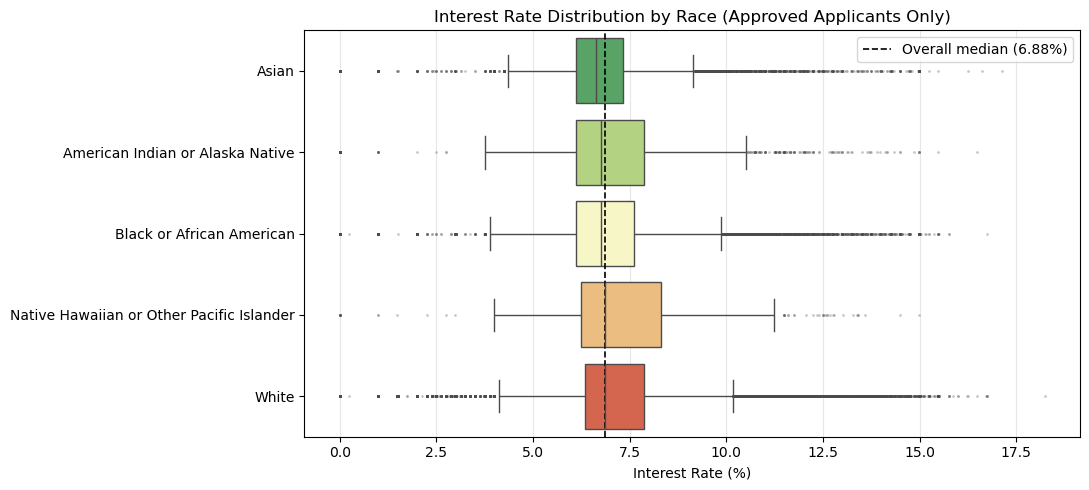

In [14]:
# Step 13: Interest Rate by Race (Approved Applicants Only)

EXCLUDE_SMALL = ['Free Form Text Only']
FOCUS_RACES = ['White', 'Black or African American', 'Asian',
               'American Indian or Alaska Native',
               'Native Hawaiian or Other Pacific Islander']

df_approved = df[(df['approved'] == 1) & (df['interest_rate'].notna())].copy()

print(f'Approved applicants with recorded interest rate: {len(df_approved):,}')
print(f'Overall median interest rate: {df_approved["interest_rate"].median():.3f}%')
print(f'Overall mean interest rate:   {df_approved["interest_rate"].mean():.3f}%')

# Summary table by race
rate_by_race = (
    df_approved[df_approved['derived_race'].isin(FOCUS_RACES)]
    .groupby('derived_race')['interest_rate']
    .agg(n='count', mean='mean', median='median', std='std',
         p25=lambda x: x.quantile(0.25),
         p75=lambda x: x.quantile(0.75))
    .sort_values('median')
    .round(4)
)
print('\nInterest Rate by Race (Approved Applicants Only):')
print(rate_by_race.to_string())

# Box plot
overall_median_rate = df_approved['interest_rate'].median()
plot_df = df_approved[df_approved['derived_race'].isin(FOCUS_RACES)]
order = plot_df.groupby('derived_race')['interest_rate'].median().sort_values().index

fig, ax = plt.subplots(figsize=(11, 5))
sns.boxplot(data=plot_df, y='derived_race', x='interest_rate', order=order,
            ax=ax, palette='RdYlGn_r',
            flierprops={'marker': '.', 'markersize': 2, 'alpha': 0.3})
ax.axvline(overall_median_rate, color='black', linestyle='--', linewidth=1.2,
           label=f'Overall median ({overall_median_rate:.2f}%)')
ax.set_xlabel('Interest Rate (%)')
ax.set_ylabel('')
ax.set_title('Interest Rate Distribution by Race (Approved Applicants Only)')
ax.legend()
ax.grid(alpha=0.3, axis='x')
plt.tight_layout()
plt.show()

### Step 14 | Interest Rate Distribution by Ethnicity and Sex

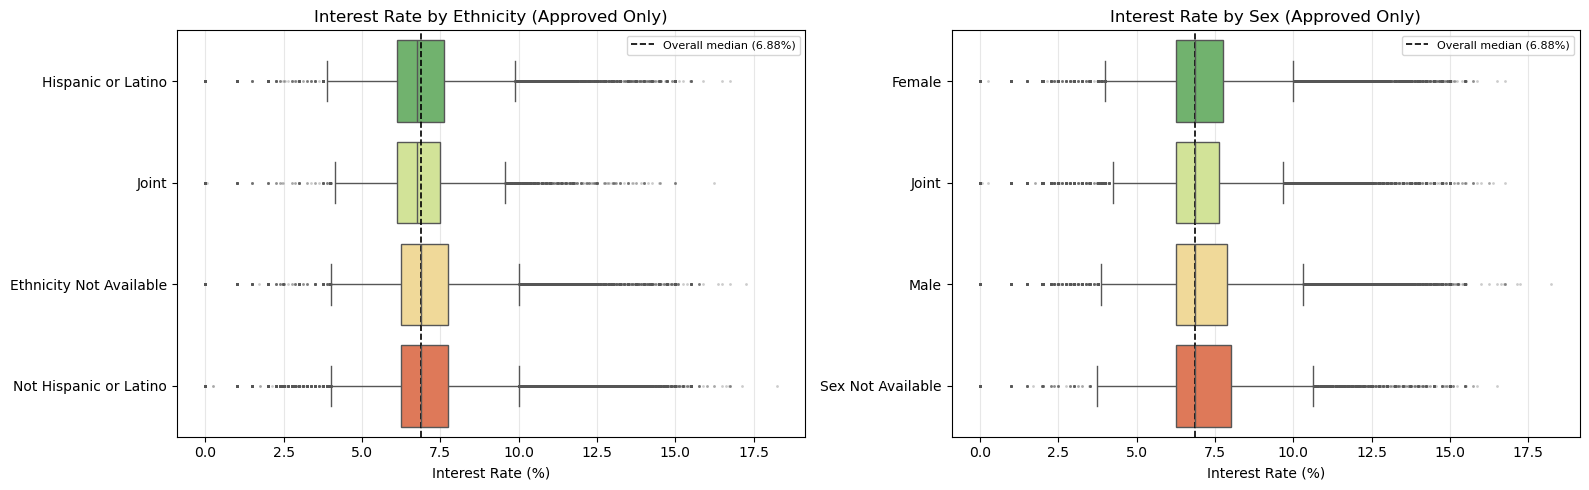

Interest Rate by Ethnicity:
                              n    mean  median     std
derived_ethnicity                                      
Hispanic or Latino        39202  6.9776   6.750  1.9071
Joint                      9452  6.9587   6.750  1.6201
Ethnicity Not Available   43377  7.1944   6.875  1.8182
Not Hispanic or Latino   242247  7.1731   6.875  1.6938

Interest Rate by Sex:
                        n    mean  median     std
derived_sex                                      
Female              72759  7.1301   6.875  1.8499
Joint              129199  7.0797   6.875  1.5523
Male               113010  7.2123   6.875  1.8254
Sex Not Available   19401  7.2748   6.875  1.8919



In [15]:
# Step 14: Interest Rate by Ethnicity and Sex

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

for ax, (col, label, exclude) in zip(axes, [
    ('derived_ethnicity', 'Ethnicity', EXCLUDE_SMALL),
    ('derived_sex',       'Sex',       [])
]):
    plot_df2 = df_approved[~df_approved[col].isin(exclude)]
    order2 = plot_df2.groupby(col)['interest_rate'].median().sort_values().index
    sns.boxplot(data=plot_df2, y=col, x='interest_rate', order=order2,
                ax=ax, palette='RdYlGn_r',
                flierprops={'marker': '.', 'markersize': 2, 'alpha': 0.3})
    ax.axvline(overall_median_rate, color='black', linestyle='--', linewidth=1.2,
               label=f'Overall median ({overall_median_rate:.2f}%)')
    ax.set_xlabel('Interest Rate (%)')
    ax.set_ylabel('')
    ax.set_title(f'Interest Rate by {label} (Approved Only)')
    ax.legend(fontsize=8)
    ax.grid(alpha=0.3, axis='x')

plt.tight_layout()
plt.show()

# Summary tables
for col, label, exclude in [
    ('derived_ethnicity', 'Ethnicity', EXCLUDE_SMALL),
    ('derived_sex',       'Sex',       [])
]:
    tbl = (
        df_approved[~df_approved[col].isin(exclude)]
        .groupby(col)['interest_rate']
        .agg(n='count', mean='mean', median='median', std='std')
        .sort_values('median')
        .round(4)
    )
    print(f'Interest Rate by {label}:')
    print(tbl.to_string())
    print()

### Step 15 | Rate Spread by Race
Rate spread controls for loan type differences and is therefore a more precise fairness indicator. A positive rate spread means the loan is priced above the benchmark for comparable products.

Approved applicants with recorded rate spread: 314,976
Overall median rate spread: 0.3540

Rate Spread by Race (Approved Applicants Only):
                                                n    mean  median     std
derived_race                                                             
Asian                                       19926  0.2764  0.1000  1.3304
White                                      216307  0.5766  0.3720  2.0171
American Indian or Alaska Native             2036  0.6554  0.4005  1.8967
Black or African American                   23561  0.6038  0.4370  1.8837
Native Hawaiian or Other Pacific Islander     647  0.7249  0.4450  1.9167


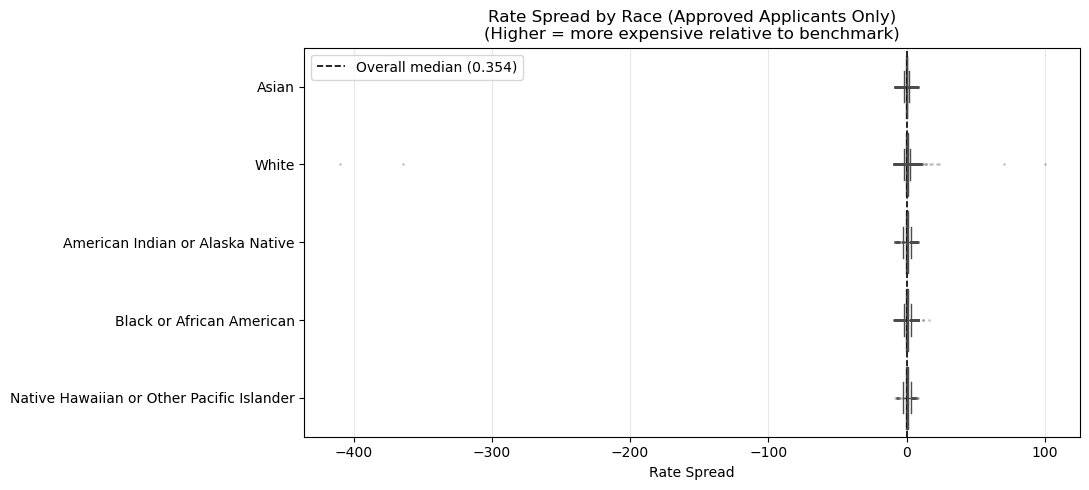

In [16]:
# Step 15: Rate Spread by Race

df_spread = df[(df['approved'] == 1) & (df['rate_spread'].notna())].copy()

print(f'Approved applicants with recorded rate spread: {len(df_spread):,}')
print(f'Overall median rate spread: {df_spread["rate_spread"].median():.4f}')

spread_by_race = (
    df_spread[df_spread['derived_race'].isin(FOCUS_RACES)]
    .groupby('derived_race')['rate_spread']
    .agg(n='count', mean='mean', median='median', std='std')
    .sort_values('median')
    .round(4)
)
print('\nRate Spread by Race (Approved Applicants Only):')
print(spread_by_race.to_string())

overall_median_spread = df_spread['rate_spread'].median()
plot_df3 = df_spread[df_spread['derived_race'].isin(FOCUS_RACES)]
order3 = plot_df3.groupby('derived_race')['rate_spread'].median().sort_values().index

fig, ax = plt.subplots(figsize=(11, 5))
sns.boxplot(data=plot_df3, y='derived_race', x='rate_spread', order=order3,
            ax=ax, palette='RdYlGn_r',
            flierprops={'marker': '.', 'markersize': 2, 'alpha': 0.3})
ax.axvline(overall_median_spread, color='black', linestyle='--', linewidth=1.2,
           label=f'Overall median ({overall_median_spread:.3f})')
ax.set_xlabel('Rate Spread')
ax.set_ylabel('')
ax.set_title('Rate Spread by Race (Approved Applicants Only)\n(Higher = more expensive relative to benchmark)')
ax.legend()
ax.grid(alpha=0.3, axis='x')
plt.tight_layout()
plt.show()

---
## Part D: Making the Bias Explicit

Three additional analyses surface the bias in more direct and legally grounded terms.

### Step 16 | Denial Reasons by Race
HMDA requires lenders to report up to four reasons for denial. We examine whether the stated reasons differ across racial groups. If minority applicants are disproportionately denied for debt-to-income ratio compared to White applicants with similar DTI profiles, that is direct evidence the same financial threshold is being applied differently across groups.

Total denied applications: 98,086

Overall denial reason distribution:
denial_reason_1
Debt-to-income ratio             34827
Credit history                   24164
Collateral                       13443
Credit application incomplete    10605
Other                             7358
Unverifiable information          4237
Insufficient cash                 2448
Employment history                 988
Mortgage insurance denied           15
Exempt                               1

Denial Reason Distribution by Race (% of denials within each group):
(Each row sums to 100% — read across to compare which reasons dominate for each group)

denial_reason_1                            Collateral  Credit application incomplete  Credit history  Debt-to-income ratio  Employment history  Insufficient cash  Mortgage insurance denied  Other  Unverifiable information
derived_race                                                                                                                                   

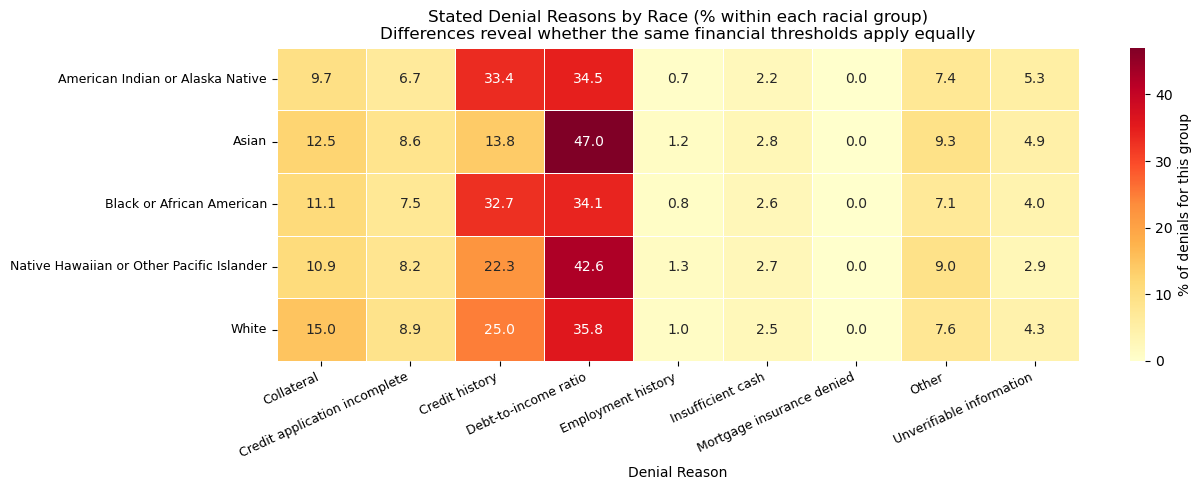

In [17]:
# Step 16: Denial Reasons by Race

df_denied = df[df['approved'] == 0].copy()

print(f'Total denied applications: {len(df_denied):,}')
print('\nOverall denial reason distribution:')
print(df_denied['denial_reason_1'].value_counts().to_string())

# Cross-tab: denial reason by race (normalised within each race)
denial_race = (
    df_denied[df_denied['derived_race'].isin(FOCUS_RACES)]
    .groupby(['derived_race', 'denial_reason_1'])
    .size()
    .unstack(fill_value=0)
)

denial_race_pct = denial_race.div(denial_race.sum(axis=1), axis=0) * 100

if 'Exempt' in denial_race_pct.columns:
    denial_race_pct = denial_race_pct.drop(columns=['Exempt'])

# Print full table explicitly so numbers are visible alongside the heatmap
print('\nDenial Reason Distribution by Race (% of denials within each group):')
print('(Each row sums to 100% — read across to compare which reasons dominate for each group)')
print()
print(denial_race_pct.round(1).to_string())

# Raw counts table for context
print('\nRaw denial counts by race and reason:')
denial_race_counts = denial_race.copy()
if 'Exempt' in denial_race_counts.columns:
    denial_race_counts = denial_race_counts.drop(columns=['Exempt'])
print(denial_race_counts.to_string())

# Heatmap
fig, ax = plt.subplots(figsize=(13, 5))
sns.heatmap(denial_race_pct, annot=True, fmt='.1f', cmap='YlOrRd',
            linewidths=0.5, ax=ax,
            cbar_kws={'label': '% of denials for this group'})
ax.set_title('Stated Denial Reasons by Race (% within each racial group)\n'
             'Differences reveal whether the same financial thresholds apply equally')
ax.set_xlabel('Denial Reason')
ax.set_ylabel('')
ax.set_yticklabels(ax.get_yticklabels(), rotation=0, fontsize=9)
ax.set_xticklabels(ax.get_xticklabels(), rotation=25, ha='right', fontsize=9)
plt.tight_layout()
plt.show()

### Step 17 | Disparate Impact Ratio (The 80% Rule)
The Disparate Impact Ratio divides a group's approval rate by the approval rate of the most favoured group. A ratio below 0.80 constitutes disparate impact under the US Equal Credit Opportunity Act and triggers fair lending scrutiny. HMDA data is the primary dataset used in regulatory fair lending examinations.

Disparate Impact by Race (reference: Asian):
                                    Group  Approval Rate (%)  Disparate Impact Ratio Passes 80% Rule
                 2 or more minority races              63.57                   0.792            FAIL
Native Hawaiian or Other Pacific Islander              64.26                   0.801            Pass
                Black or African American              65.66                   0.818            Pass
         American Indian or Alaska Native              65.70                   0.819            Pass
                                    White              80.05                   0.998            Pass
                                    Asian              80.24                   1.000            Pass
Groups failing the 80% rule: 1 of 6

Disparate Impact by Ethnicity (reference: Not Hispanic or Latino):
                 Group  Approval Rate (%)  Disparate Impact Ratio Passes 80% Rule
    Hispanic or Latino              71.88                   0.

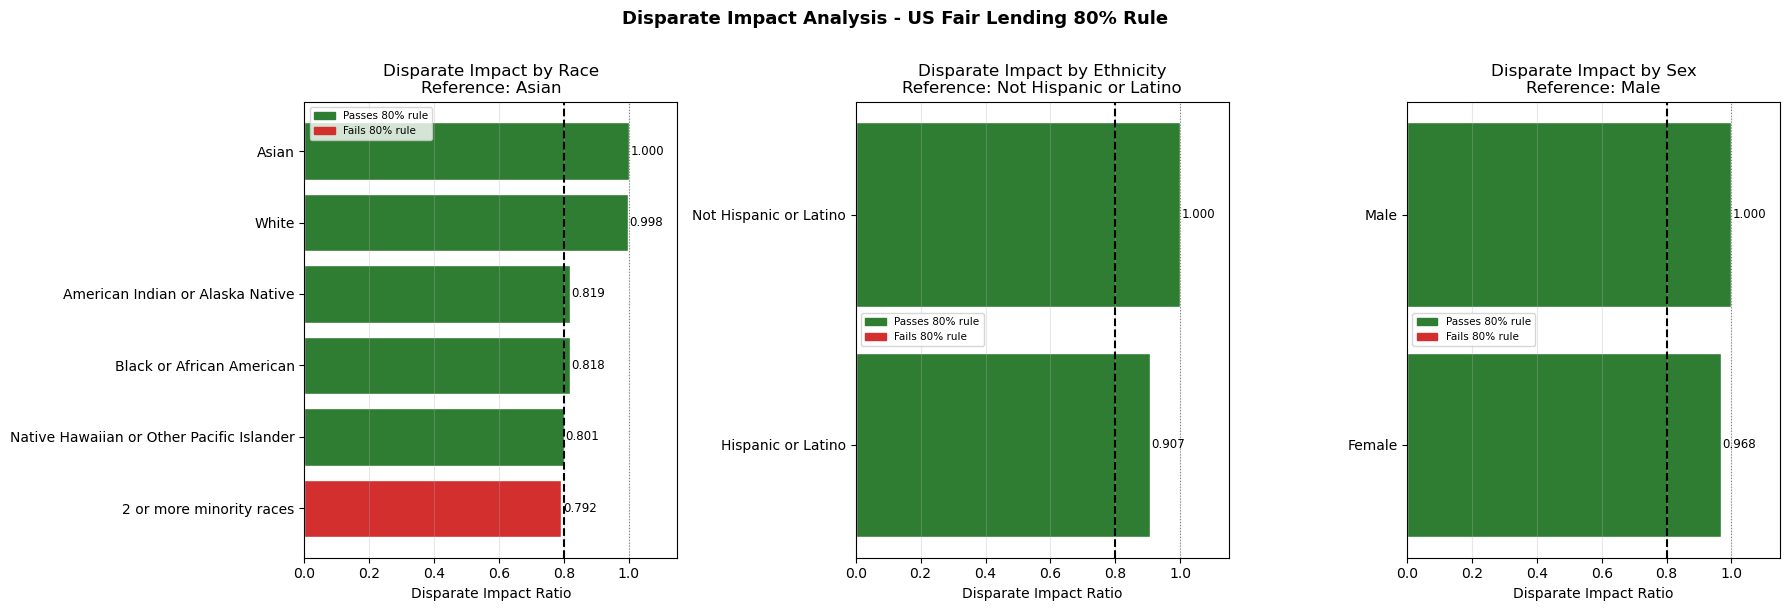

In [18]:
# Step 17: Disparate Impact Ratio

EXCLUDE_AMBIGUOUS = ['Free Form Text Only', 'Joint', 'Race Not Available',
                     'Ethnicity Not Available', 'Sex Not Available']

def disparate_impact_table(rates_series, exclude=None):
    if exclude is None:
        exclude = []
    rates = rates_series[~rates_series.index.isin(exclude)]
    max_rate = rates.max()
    reference = rates.idxmax()
    t = rates.reset_index()
    t.columns = ['Group', 'Approval Rate (%)']
    t['Approval Rate (%)'] = (t['Approval Rate (%)'] * 100).round(2)
    t['Disparate Impact Ratio'] = (t['Approval Rate (%)'] / (max_rate * 100)).round(3)
    t['Passes 80% Rule'] = t['Disparate Impact Ratio'].apply(
        lambda x: 'Pass' if x >= 0.80 else 'FAIL'
    )
    return t.sort_values('Disparate Impact Ratio'), reference

race_rates = df[~df['derived_race'].isin(EXCLUDE_AMBIGUOUS)].groupby('derived_race')['approved'].mean()
eth_rates  = df[~df['derived_ethnicity'].isin(EXCLUDE_AMBIGUOUS)].groupby('derived_ethnicity')['approved'].mean()
sex_rates  = df[~df['derived_sex'].isin(EXCLUDE_AMBIGUOUS)].groupby('derived_sex')['approved'].mean()

di_race, ref_race = disparate_impact_table(race_rates)
di_eth,  ref_eth  = disparate_impact_table(eth_rates)
di_sex,  ref_sex  = disparate_impact_table(sex_rates)

for label, table, ref in [('Race', di_race, ref_race),
                           ('Ethnicity', di_eth, ref_eth),
                           ('Sex', di_sex, ref_sex)]:
    print(f'Disparate Impact by {label} (reference: {ref}):')
    print(table.to_string(index=False))
    fails = (table['Passes 80% Rule'] == 'FAIL').sum()
    print(f'Groups failing the 80% rule: {fails} of {len(table)}')
    print()

fig, axes = plt.subplots(1, 3, figsize=(18, 6))

for ax, (label, table, ref) in zip(axes, [
    ('Race',      di_race, ref_race),
    ('Ethnicity', di_eth,  ref_eth),
    ('Sex',       di_sex,  ref_sex)
]):
    colors = ['#d32f2f' if v < 0.80 else '#2e7d32' for v in table['Disparate Impact Ratio']]
    bars = ax.barh(table['Group'], table['Disparate Impact Ratio'], color=colors, edgecolor='white')
    ax.axvline(0.80, color='black', linewidth=1.5, linestyle='--', label='80% threshold')
    ax.axvline(1.00, color='grey', linewidth=0.8, linestyle=':')

    for bar, val in zip(bars, table['Disparate Impact Ratio']):
        ax.text(val + 0.005, bar.get_y() + bar.get_height() / 2,
                f'{val:.3f}', va='center', fontsize=8.5)

    ax.set_xlabel('Disparate Impact Ratio')
    ax.set_title(f'Disparate Impact by {label}\nReference: {ref}')
    ax.set_xlim(0, 1.15)
    ax.legend(fontsize=7.5)
    ax.grid(alpha=0.3, axis='x')

    fail_patch = mpatches.Patch(color='#d32f2f', label='Fails 80% rule')
    pass_patch = mpatches.Patch(color='#2e7d32', label='Passes 80% rule')
    ax.legend(handles=[pass_patch, fail_patch], fontsize=7.5)

plt.suptitle('Disparate Impact Analysis - US Fair Lending 80% Rule',
             fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

### Step 18 | Predicted Probability Distributions by Race
We plot the full distribution of the model's predicted approval probabilities by race. If the model were race-neutral, these distributions would look similar across groups. Systematic differences reveal model-level bias before any threshold is applied.

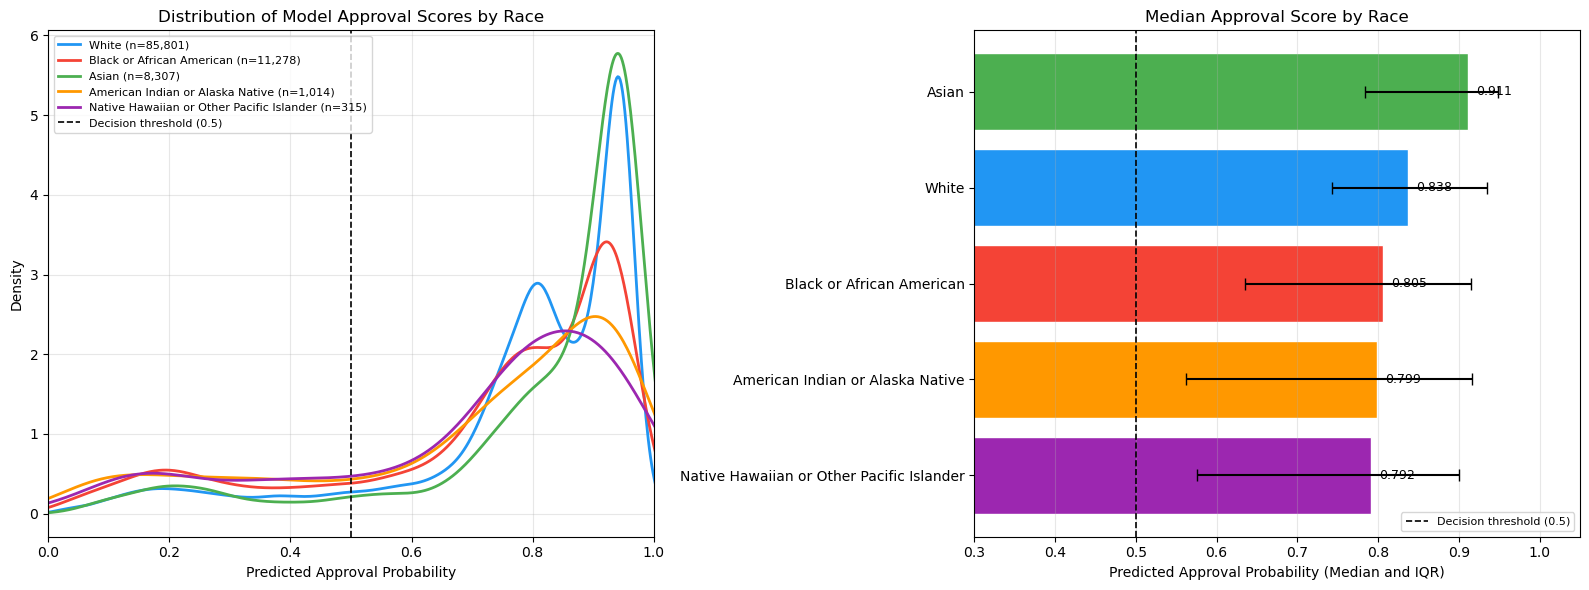

In [19]:
# Step 18: Predicted Probability Distributions by Race

palette = {
    'White':                                    '#2196F3',
    'Black or African American':                '#F44336',
    'Asian':                                    '#4CAF50',
    'American Indian or Alaska Native':         '#FF9800',
    'Native Hawaiian or Other Pacific Islander':'#9C27B0'
}

plot_df4 = demo_test[demo_test['derived_race'].isin(FOCUS_RACES)].copy()

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

ax = axes[0]
for race in FOCUS_RACES:
    subset = plot_df4[plot_df4['derived_race'] == race]['predicted_prob']
    if len(subset) < 50:
        continue
    subset.plot.kde(ax=ax, label=f'{race} (n={len(subset):,})',
                   color=palette[race], linewidth=2)

ax.axvline(0.5, color='black', linestyle='--', linewidth=1.2, label='Decision threshold (0.5)')
ax.set_xlabel('Predicted Approval Probability')
ax.set_ylabel('Density')
ax.set_title('Distribution of Model Approval Scores by Race')
ax.set_xlim(0, 1)
ax.legend(fontsize=8)
ax.grid(alpha=0.3)

ax2 = axes[1]
summary = (
    plot_df4[plot_df4['derived_race'].isin(FOCUS_RACES)]
    .groupby('derived_race')['predicted_prob']
    .agg(['median', 'mean',
          lambda x: x.quantile(0.25),
          lambda x: x.quantile(0.75)])
)
summary.columns = ['median', 'mean', 'p25', 'p75']
summary = summary.sort_values('median')

colors_bar = [palette.get(r, 'grey') for r in summary.index]
ax2.barh(summary.index, summary['median'],
         xerr=[summary['median'] - summary['p25'], summary['p75'] - summary['median']],
         color=colors_bar, edgecolor='white',
         error_kw={'elinewidth': 1.5, 'capsize': 4, 'ecolor': 'black'})
ax2.axvline(0.5, color='black', linestyle='--', linewidth=1.2, label='Decision threshold (0.5)')

for i, (idx, row) in enumerate(summary.iterrows()):
    ax2.text(row['median'] + 0.01, i, f'{row["median"]:.3f}', va='center', fontsize=9)

ax2.set_xlabel('Predicted Approval Probability (Median and IQR)')
ax2.set_title('Median Approval Score by Race')
ax2.set_xlim(0.3, 1.05)
ax2.legend(fontsize=8)
ax2.grid(alpha=0.3, axis='x')

plt.tight_layout()
plt.show()

### Step 19 | Feature Distributions by Race (RQ1 Integration)
The top predictive features identified in RQ1 (income, loan amount, property value, combined loan-to-value ratio, DTI, and age) are themselves unequally distributed across racial groups. This demonstrates the mechanism of proxy discrimination: the model never sees race, but the features it relies on most are correlated with race due to structural inequality. This is why close model metrics do not exonerate the system.

Visualisation clip ranges applied (for chart only, not analysis):
  income: [1, 359] — 22,175 rows outside range (6.23%)
  loan_amount: [0, 705000] — 16,959 rows outside range (4.77%)
  property_value: [0, 1205000] — 17,577 rows outside range (4.94%)
  combined_loan_to_value_ratio: [0, 120] — 683 rows outside range (0.19%)


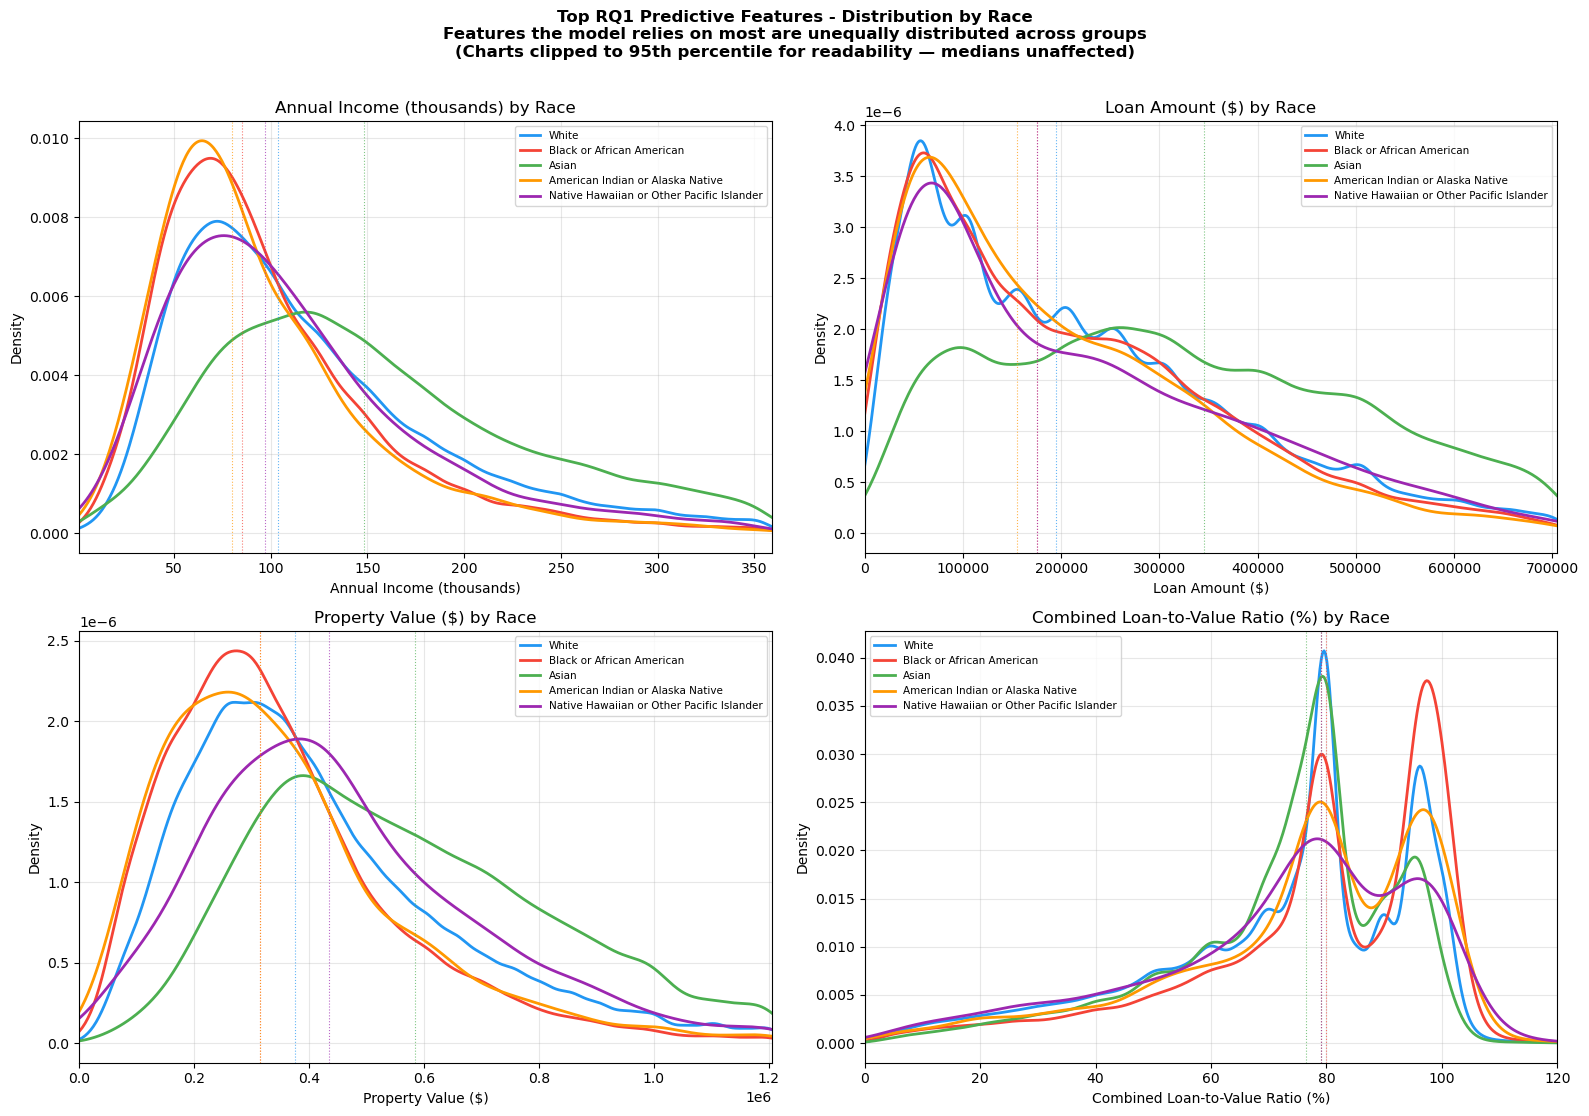

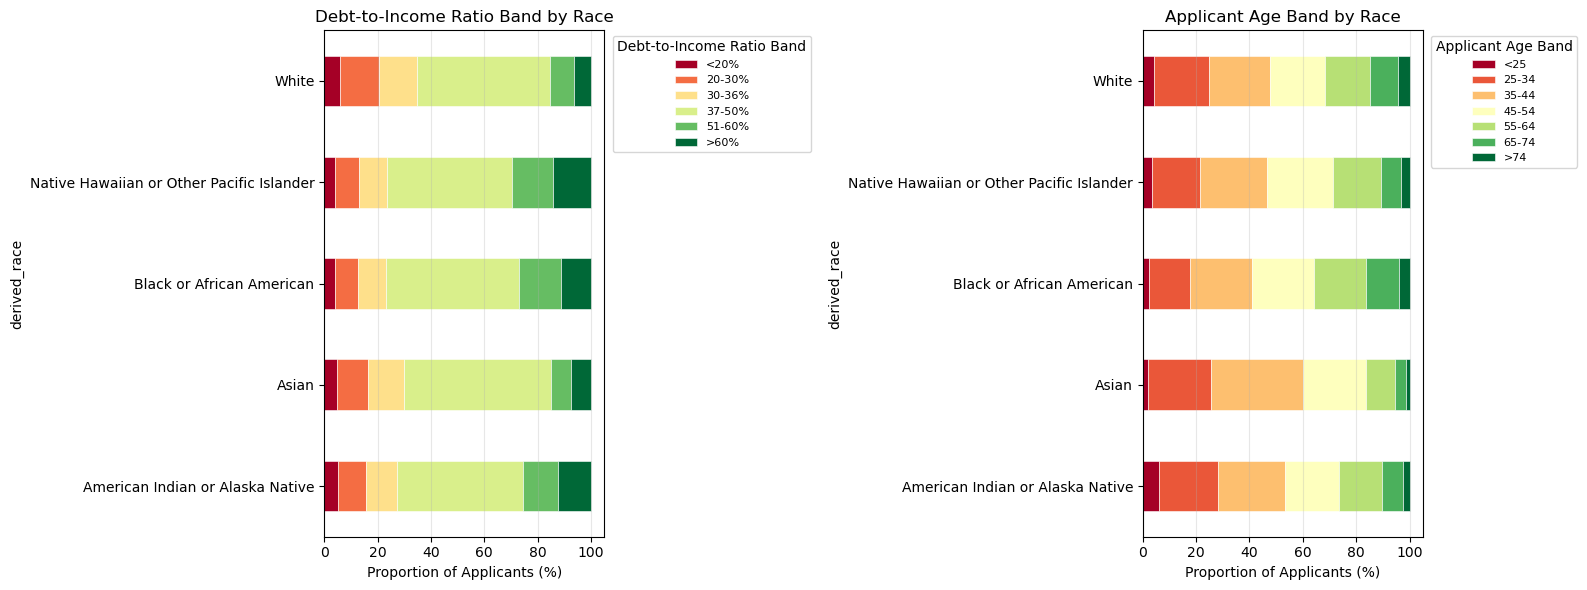

Median feature values by race (computed on full unclipped data):
                                           Annual Income (thousands)  Loan Amount ($)  Property Value ($)  Combined Loan-to-Value Ratio (%)
derived_race                                                                                                                               
American Indian or Alaska Native                                80.0         155000.0            315000.0                              79.0
Black or African American                                       85.0         175000.0            315000.0                              80.0
Native Hawaiian or Other Pacific Islander                       97.0         175000.0            435000.0                              79.0
White                                                          104.0         195000.0            375000.0                              79.0
Asian                                                          148.0         345000.0          

In [26]:
# Step 19: Feature Distributions by Race
# Note: Income has 295 negative values (min -$42.9M) and property_value has
# a max of 2,147,483,647 (INT32 sentinel value) — both are HMDA source data
# anomalies. Clips below are applied for VISUALISATION ONLY.
# All analytical conclusions use medians which are robust to these outliers.

CONTINUOUS_FEATURES = {
    'income':                       'Annual Income (thousands)',
    'loan_amount':                  'Loan Amount ($)',
    'property_value':               'Property Value ($)',
    'combined_loan_to_value_ratio': 'Combined Loan-to-Value Ratio (%)'
}

ORDINAL_FEATURES = {
    'dti_ordinal': ('Debt-to-Income Ratio Band',
                    {1:'<20%', 2:'20-30%', 3:'30-36%', 4:'37-50%', 5:'51-60%', 6:'>60%'}),
    'age_ordinal': ('Applicant Age Band',
                    {1:'<25', 2:'25-34', 3:'35-44', 4:'45-54', 5:'55-64', 6:'65-74', 7:'>74'})
}

df_race_plot = df[df['derived_race'].isin(FOCUS_RACES)].copy()

# Per-feature visualisation clips — floor and ceiling both specified
# Upper = 95th percentile to show the bulk of each distribution cleanly
# Lower = 0 for income (removes negative anomalies), natural min for others
# Zero income rows (n=5,456) are excluded from the KDE plot only to remove
# the spike artifact at zero — they are retained in all analytical computations
VIZ_CLIPS = {
    'income':                       (1,   df_race_plot['income'].quantile(0.95)),
    'loan_amount':                  (0,   df_race_plot['loan_amount'].quantile(0.95)),
    'property_value':               (0,   df_race_plot['property_value'].quantile(0.95)),
    'combined_loan_to_value_ratio': (0,   120)
}

print('Visualisation clip ranges applied (for chart only, not analysis):')
for col, (lo, hi) in VIZ_CLIPS.items():
    total = len(df_race_plot)
    clipped = ((df_race_plot[col] < lo) | (df_race_plot[col] > hi)).sum()
    print(f'  {col}: [{lo:.0f}, {hi:.0f}] — {clipped:,} rows outside range ({round(clipped/total*100,2)}%)')

# ── Panel 1: Continuous features — KDE by race ──
fig, axes = plt.subplots(2, 2, figsize=(16, 11))
axes = axes.flatten()

for ax, (col, label) in zip(axes, CONTINUOUS_FEATURES.items()):
    lo, hi = VIZ_CLIPS[col]
    temp = df_race_plot.copy()

    # Clip to visualisation range before KDE fitting
    temp = temp[(temp[col] >= lo) & (temp[col] <= hi)]

    for race in FOCUS_RACES:
        subset = temp[temp['derived_race'] == race][col].dropna()
        if len(subset) < 50:
            continue
        subset.plot.kde(ax=ax, label=race, color=palette[race], linewidth=2)

    # Median lines computed on FULL unclipped data — medians are robust to outliers
    medians = df_race_plot.groupby('derived_race')[col].median()
    for race in FOCUS_RACES:
        if race in medians.index:
            med = medians[race]
            if lo <= med <= hi:
                ax.axvline(med, color=palette[race], linewidth=0.8,
                           linestyle=':', alpha=0.7)

    # Lock axis to the clipped range so KDE smoothing cannot bleed outside it
    ax.set_xlim(left=lo, right=hi)
    ax.set_xlabel(label)
    ax.set_ylabel('Density')
    ax.set_title(f'{label} by Race')
    ax.legend(fontsize=7.5)
    ax.grid(alpha=0.3)

plt.suptitle('Top RQ1 Predictive Features - Distribution by Race\n'
             'Features the model relies on most are unequally distributed across groups\n'
             '(Charts clipped to 95th percentile for readability — medians unaffected)',
             fontsize=12, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

# ── Panel 2: Ordinal features — stacked normalised bar charts ──
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

for ax, (col, (label, tick_labels)) in zip(axes, ORDINAL_FEATURES.items()):
    cross = (
        df_race_plot.groupby(['derived_race', col])
        .size()
        .unstack(fill_value=0)
    )
    cross_pct = cross.div(cross.sum(axis=1), axis=0) * 100
    cross_pct = cross_pct.rename(columns=tick_labels)
    cross_pct.plot(kind='barh', stacked=True, ax=ax,
                   colormap='RdYlGn', edgecolor='white', linewidth=0.4)
    ax.set_xlabel('Proportion of Applicants (%)')
    ax.set_title(f'{label} by Race')
    ax.set_xlim(0, 105)
    ax.legend(title=label, bbox_to_anchor=(1.01, 1), loc='upper left', fontsize=8)
    ax.grid(alpha=0.3, axis='x')

plt.tight_layout()
plt.show()

# ── Summary table: medians on FULL unclipped data ──
print('Median feature values by race (computed on full unclipped data):')
summary_tbl = df_race_plot.groupby('derived_race')[list(CONTINUOUS_FEATURES.keys())].median().round(1)
summary_tbl.columns = list(CONTINUOUS_FEATURES.values())
print(summary_tbl.sort_values('Annual Income (thousands)').to_string())

---
## Part E: Association Rules - Which Feature Combinations Drive Denial?

Association rules identify which specific combinations of financial characteristics appear together most strongly with denial outcomes. We then check whether those combinations disproportionately describe minority applicants, directly linking the patterns the model acts on to the groups they affect.

### Step 20 | Discretise Features and Build Transaction Matrix

In [21]:
# Step 20: Discretise Features and Build Transaction Matrix

df_ar = df.copy()

df_ar['income_band'] = pd.cut(
    df_ar['income'].clip(lower=0),
    bins=[0, 60, 120, float('inf')],
    labels=['income_low', 'income_mid', 'income_high'],
    right=True
)

df_ar['loan_band'] = pd.cut(
    df_ar['loan_amount'],
    bins=[0, 150000, 400000, float('inf')],
    labels=['loan_small', 'loan_mid', 'loan_large'],
    right=True
)

df_ar['dti_band'] = df_ar['dti_ordinal'].map({
    1: 'dti_low',  2: 'dti_low',
    3: 'dti_mid',  4: 'dti_mid',
    5: 'dti_high', 6: 'dti_high'
})

df_ar['age_band'] = df_ar['age_ordinal'].map({
    1: 'age_young', 2: 'age_young',
    3: 'age_mid',   4: 'age_mid',   5: 'age_mid',
    6: 'age_older', 7: 'age_older'
})

df_ar['clvr_band'] = pd.cut(
    df_ar['combined_loan_to_value_ratio'].clip(0, 200),
    bins=[0, 80, 95, 200],
    labels=['clvr_low', 'clvr_mid', 'clvr_high'],
    right=True
)

df_ar['outcome'] = df_ar['approved'].map({1: 'approved', 0: 'denied'})

item_cols = ['income_band', 'loan_band', 'dti_band', 'age_band', 'clvr_band', 'outcome']
df_items = df_ar[item_cols].dropna()

transactions = df_items.apply(lambda row: [str(v) for v in row], axis=1).tolist()

te = TransactionEncoder()
te_ary = te.fit(transactions).transform(transactions)
trans_df = pd.DataFrame(te_ary, columns=te.columns_)

print('Transaction matrix shape:', trans_df.shape)
print('Total transactions:', f'{len(trans_df):,}')
print('Denial rate in transactions:', round(trans_df['denied'].mean() * 100, 2), '%')

Transaction matrix shape: (427362, 17)
Total transactions: 427,362
Denial rate in transactions: 22.28 %


### Step 21 | Mine Association Rules for Denial

Frequent itemsets found: 1,041
High-lift denial rules (lift > 1.5): 57

Top 15 rules by lift:
                                         antecedent_str  support  confidence   lift
age_mid + clvr_low + dti_high + income_low + loan_small   0.0136      0.8587 3.8534
           age_mid + dti_high + income_low + loan_small   0.0162      0.8506 3.8168
          clvr_low + dti_high + income_low + loan_small   0.0239      0.8454 3.7938
             age_mid + clvr_low + dti_high + income_low   0.0195      0.8415 3.7763
                     dti_high + income_low + loan_small   0.0284      0.8326 3.7364
                       clvr_low + dti_high + income_low   0.0339      0.8283 3.7167
                        age_mid + dti_high + income_low   0.0251      0.8040 3.6078
                                  dti_high + income_low   0.0440      0.7773 3.4881
                      age_older + dti_high + income_low   0.0107      0.7701 3.4556
                       clvr_low + dti_high + loan_small   0.0410  

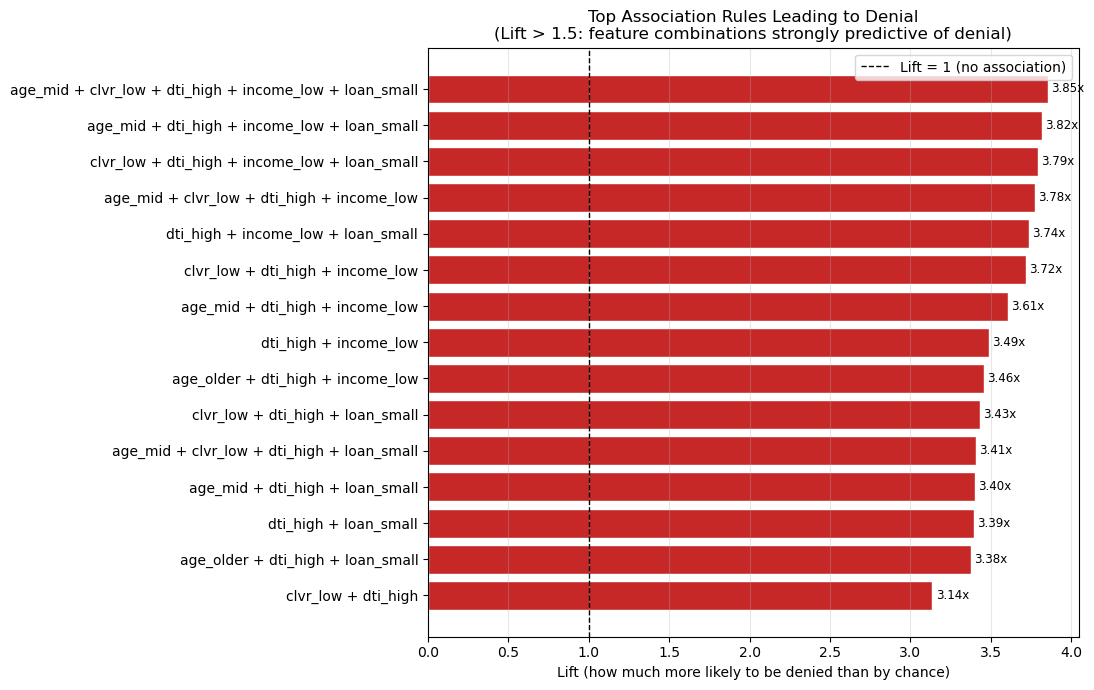

In [22]:
# Step 21: Mine Association Rules

frequent_itemsets = apriori(trans_df, min_support=0.01, use_colnames=True)
print(f'Frequent itemsets found: {len(frequent_itemsets):,}')

all_rules = association_rules(frequent_itemsets, metric='lift', min_threshold=1.0)

denial_rules = all_rules[
    (all_rules['consequents'] == frozenset({'denied'})) &
    (all_rules['lift'] > 1.5)
].copy()

denial_rules['antecedent_str'] = denial_rules['antecedents'].apply(
    lambda x: ' + '.join(sorted(x))
)
denial_rules = denial_rules.sort_values('lift', ascending=False)

print(f'High-lift denial rules (lift > 1.5): {len(denial_rules)}')
print('\nTop 15 rules by lift:')
print(
    denial_rules[['antecedent_str', 'support', 'confidence', 'lift']]
    .head(15)
    .round(4)
    .to_string(index=False)
)

top_rules = denial_rules.head(15).sort_values('lift')

fig, ax = plt.subplots(figsize=(11, 7))
bars = ax.barh(top_rules['antecedent_str'], top_rules['lift'],
               color='#c62828', edgecolor='white')

for bar, val in zip(bars, top_rules['lift']):
    ax.text(val + 0.02, bar.get_y() + bar.get_height() / 2,
            f'{val:.2f}x', va='center', fontsize=8.5)

ax.axvline(1.0, color='black', linewidth=1, linestyle='--', label='Lift = 1 (no association)')
ax.set_xlabel('Lift (how much more likely to be denied than by chance)')
ax.set_title('Top Association Rules Leading to Denial\n(Lift > 1.5: feature combinations strongly predictive of denial)')
ax.legend()
ax.grid(alpha=0.3, axis='x')
plt.tight_layout()
plt.show()

### Step 22 | Demographic Exposure to High-Lift Denial Rules
We check which racial groups are over-represented among applicants whose profiles match the high-lift denial rules. Over-representation confirms that the financial patterns the model acts on systematically describe minority applicants more than majority applicants.

Demographic over-representation in high-lift denial rules (percentage points):
Rule                                       age_mid + clvr_low + dti_high + income_low  age_mid + clvr_low + dti_high + income_low + loan_small  age_mid + dti_high + income_low  age_mid + dti_high + income_low + loan_small  clvr_low + dti_high + income_low  clvr_low + dti_high + income_low + loan_small  dti_high + income_low  dti_high + income_low + loan_small
Race                                                                                                                                                                                                                                                                                                                                                                     
American Indian or Alaska Native                                                 0.84                                                     0.90                             0.88                      

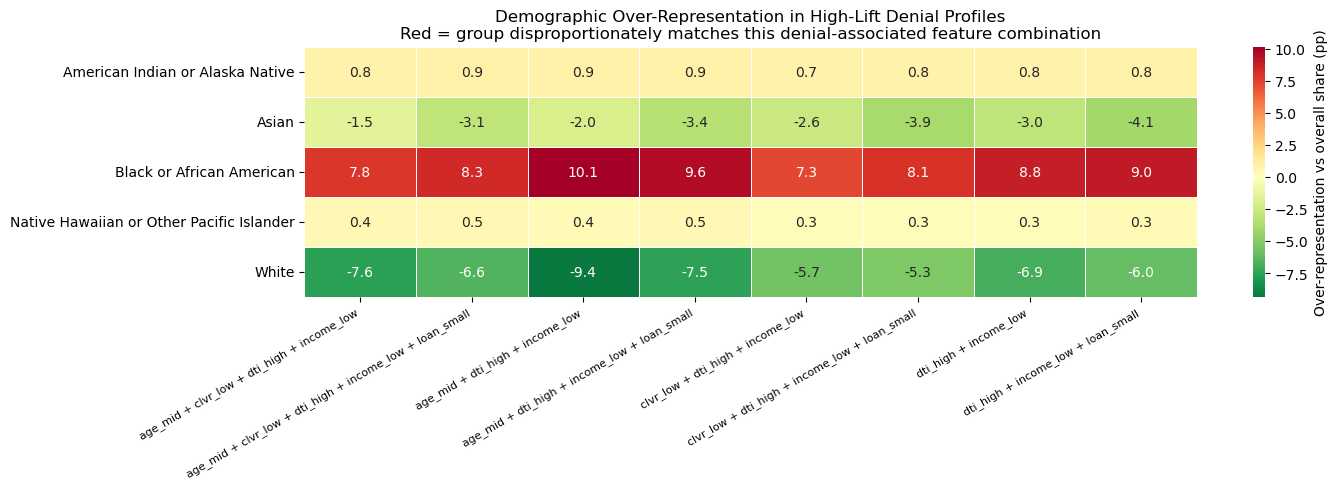


Average over-representation across all high-lift denial rules:
Race
White                                       -6.86
Asian                                       -2.95
Native Hawaiian or Other Pacific Islander    0.36
American Indian or Alaska Native             0.83
Black or African American                    8.62


In [23]:
# Step 22: Demographic Exposure to High-Lift Denial Rules

df_items_race = df_ar[item_cols + ['derived_race']].dropna(subset=item_cols).copy()
df_items_race = df_items_race[df_items_race['derived_race'].isin(FOCUS_RACES)]

top_n = min(8, len(denial_rules))
top_denial_rules = denial_rules.head(top_n)

exposure_rows = []

for _, rule in top_denial_rules.iterrows():
    antecedents = list(rule['antecedents'])
    rule_label  = rule['antecedent_str']

    mask = pd.Series([True] * len(df_items_race), index=df_items_race.index)
    for item in antecedents:
        item_mask = df_items_race[item_cols[:-1]].apply(
            lambda col: col.astype(str) == item, axis=0
        ).any(axis=1)
        mask = mask & item_mask

    matched = df_items_race[mask]
    if len(matched) < 10:
        continue

    race_dist   = matched['derived_race'].value_counts(normalize=True) * 100
    overall_dist = df_items_race['derived_race'].value_counts(normalize=True) * 100

    for race in FOCUS_RACES:
        exposure_rows.append({
            'Rule': rule_label,
            'Race': race,
            'Lift': round(rule['lift'], 3),
            'N matched': len(matched),
            'Rule exposure (%)': round(race_dist.get(race, 0), 2),
            'Overall share (%)': round(overall_dist.get(race, 0), 2),
            'Over-representation': round(
                race_dist.get(race, 0) - overall_dist.get(race, 0), 2
            )
        })

exposure_df = pd.DataFrame(exposure_rows)
pivot = exposure_df.pivot(index='Race', columns='Rule', values='Over-representation')

print('Demographic over-representation in high-lift denial rules (percentage points):')
print(pivot.round(2).to_string())

fig, ax = plt.subplots(figsize=(max(10, len(pivot.columns) * 1.8), 5))
sns.heatmap(pivot, annot=True, fmt='.1f', cmap='RdYlGn_r',
            center=0, linewidths=0.5, ax=ax,
            cbar_kws={'label': 'Over-representation vs overall share (pp)'})
ax.set_title('Demographic Over-Representation in High-Lift Denial Profiles\n'
             'Red = group disproportionately matches this denial-associated feature combination')
ax.set_xlabel('')
ax.set_ylabel('')
ax.set_yticklabels(ax.get_yticklabels(), rotation=0)
ax.set_xticklabels(ax.get_xticklabels(), rotation=30, ha='right', fontsize=8)
plt.tight_layout()
plt.show()

print('\nAverage over-representation across all high-lift denial rules:')
print(exposure_df.groupby('Race')['Over-representation'].mean().sort_values().round(2).to_string())

---
## Part F: Intersectional Analysis - Race and Sex Combined

The analyses above examine race, ethnicity, and sex independently. But applicants hold multiple identities simultaneously, and the disadvantages they face may compound at the intersection. A Black female applicant may face barriers that are larger than either the race gap or the sex gap alone would suggest.

We compute approval rates and model prediction rates for race crossed with sex, focusing on the five main racial groups and the three clearly defined sex categories (Female, Male, Joint). This reveals whether certain intersectional groups face compounding disadvantage.

Actual Approval Rates by Race x Sex (%):
derived_sex                                Female  Joint   Male
derived_race                                                   
Native Hawaiian or Other Pacific Islander   59.72  71.69  63.43
American Indian or Alaska Native            64.20  68.32  66.15
Black or African American                   63.70  70.28  65.38
White                                       76.03  84.58  77.64
Asian                                       78.13  83.66  78.82

Overall approval rate: 77.36%

Predicted Approval Rates by Race x Sex (%) - Test Set:
derived_sex                                Female  Joint   Male
derived_race                                                   
Native Hawaiian or Other Pacific Islander   79.55  80.28  77.12
American Indian or Alaska Native            72.54  80.95  80.16
Black or African American                   79.54  85.33  81.37
White                                       85.52  92.04  88.15
Asian                                   

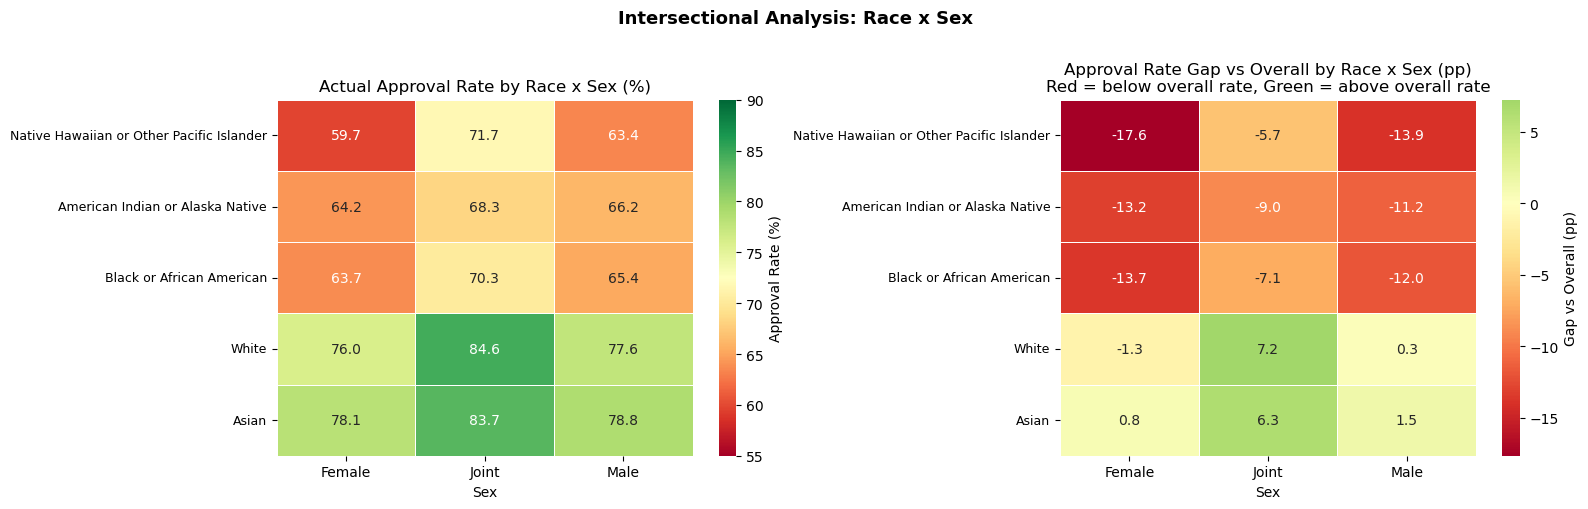


Most disadvantaged intersectional groups (lowest actual approval rates):
                             derived_race derived_sex  approval_rate_pct     n
Native Hawaiian or Other Pacific Islander      Female              59.72   283
Native Hawaiian or Other Pacific Islander        Male              63.43   484
                Black or African American      Female              63.70 16012
         American Indian or Alaska Native      Female              64.20  1081
                Black or African American        Male              65.38 14086
         American Indian or Alaska Native        Male              66.15  1666
         American Indian or Alaska Native       Joint              68.32   505
                Black or African American       Joint              70.28  7745
Native Hawaiian or Other Pacific Islander       Joint              71.69   272
                                    White      Female              76.03 65577

=== Z-Test: Black Female vs White Female ===
Black Femal

In [24]:
# Part F: Intersectional Analysis - Race x Sex

INTERSECT_RACES = ['White', 'Black or African American', 'Asian',
                   'American Indian or Alaska Native',
                   'Native Hawaiian or Other Pacific Islander']
INTERSECT_SEX   = ['Female', 'Male', 'Joint']

df_intersect = df[
    df['derived_race'].isin(INTERSECT_RACES) &
    df['derived_sex'].isin(INTERSECT_SEX)
].copy()

# ── Actual approval rates: race x sex ──
intersect_actual = (
    df_intersect
    .groupby(['derived_race', 'derived_sex'])['approved']
    .agg(['mean', 'count'])
    .rename(columns={'mean': 'approval_rate', 'count': 'n'})
    .reset_index()
)
intersect_actual['approval_rate_pct'] = (intersect_actual['approval_rate'] * 100).round(2)

pivot_actual = intersect_actual.pivot(
    index='derived_race', columns='derived_sex', values='approval_rate_pct'
)
# Sort rows by average approval rate (ascending)
pivot_actual = pivot_actual.loc[
    pivot_actual.mean(axis=1).sort_values().index
]

print('Actual Approval Rates by Race x Sex (%):')
print(pivot_actual.round(2).to_string())
print(f'\nOverall approval rate: {round(overall_rate * 100, 2)}%')

# ── Predicted approval rates: race x sex (from test set) ──
demo_test_intersect = demo_test[
    demo_test['derived_race'].isin(INTERSECT_RACES) &
    demo_test['derived_sex'].isin(INTERSECT_SEX)
].copy()

intersect_pred = (
    demo_test_intersect
    .groupby(['derived_race', 'derived_sex'])['predicted']
    .mean() * 100
).round(2).reset_index()
intersect_pred.columns = ['derived_race', 'derived_sex', 'predicted_rate_pct']

pivot_pred = intersect_pred.pivot(
    index='derived_race', columns='derived_sex', values='predicted_rate_pct'
)
pivot_pred = pivot_pred.reindex(pivot_actual.index)

print('\nPredicted Approval Rates by Race x Sex (%) - Test Set:')
print(pivot_pred.round(2).to_string())

# ── Gap from overall rate ──
pivot_gap = pivot_actual - round(overall_rate * 100, 2)
print('\nApproval Rate Gap vs Overall (pp):')
print(pivot_gap.round(2).to_string())

# ── Side by side heatmaps ──
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

sns.heatmap(
    pivot_actual, annot=True, fmt='.1f', cmap='RdYlGn',
    vmin=55, vmax=90, ax=axes[0], linewidths=0.5,
    cbar_kws={'label': 'Approval Rate (%)'}
)
axes[0].set_title('Actual Approval Rate by Race x Sex (%)')
axes[0].set_xlabel('Sex')
axes[0].set_ylabel('')
axes[0].set_yticklabels(axes[0].get_yticklabels(), rotation=0, fontsize=9)

sns.heatmap(
    pivot_gap, annot=True, fmt='.1f', cmap='RdYlGn',
    center=0, ax=axes[1], linewidths=0.5,
    cbar_kws={'label': 'Gap vs Overall (pp)'}
)
axes[1].set_title('Approval Rate Gap vs Overall by Race x Sex (pp)\n'
                  'Red = below overall rate, Green = above overall rate')
axes[1].set_xlabel('Sex')
axes[1].set_ylabel('')
axes[1].set_yticklabels(axes[1].get_yticklabels(), rotation=0, fontsize=9)

plt.suptitle('Intersectional Analysis: Race x Sex',
             fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

# ── Identify the most disadvantaged intersectional group ──
print('\nMost disadvantaged intersectional groups (lowest actual approval rates):')
intersect_sorted = intersect_actual.sort_values('approval_rate_pct').head(10)
print(intersect_sorted[['derived_race', 'derived_sex',
                         'approval_rate_pct', 'n']].to_string(index=False))

# ── Statistical significance for key intersectional gaps ──
print('\n=== Z-Test: Black Female vs White Female ===')
bf = df[(df['derived_race'] == 'Black or African American') &
        (df['derived_sex'] == 'Female')]['approved']
wf = df[(df['derived_race'] == 'White') &
        (df['derived_sex'] == 'Female')]['approved']

p_pool_bf = (bf.sum() + wf.sum()) / (len(bf) + len(wf))
se_bf     = np.sqrt(p_pool_bf * (1 - p_pool_bf) * (1/len(bf) + 1/len(wf)))
z_bf      = (bf.mean() - wf.mean()) / se_bf
p_bf      = 2 * (1 - stats.norm.cdf(abs(z_bf)))

print(f'Black Female:  {round(bf.mean()*100,2)}%  (n={len(bf):,})')
print(f'White Female:  {round(wf.mean()*100,2)}%  (n={len(wf):,})')
print(f'Gap: {round((bf.mean()-wf.mean())*100,2)} pp')
print(f'P-value: {p_bf:.2e}  --  {"Significant" if p_bf < 0.05 else "Not significant"}')

print('\n=== Z-Test: Black Male vs White Male ===')
bm = df[(df['derived_race'] == 'Black or African American') &
        (df['derived_sex'] == 'Male')]['approved']
wm = df[(df['derived_race'] == 'White') &
        (df['derived_sex'] == 'Male')]['approved']

p_pool_bm = (bm.sum() + wm.sum()) / (len(bm) + len(wm))
se_bm     = np.sqrt(p_pool_bm * (1 - p_pool_bm) * (1/len(bm) + 1/len(wm)))
z_bm      = (bm.mean() - wm.mean()) / se_bm
p_bm      = 2 * (1 - stats.norm.cdf(abs(z_bm)))

print(f'Black Male:  {round(bm.mean()*100,2)}%  (n={len(bm):,})')
print(f'White Male:  {round(wm.mean()*100,2)}%  (n={len(wm):,})')
print(f'Gap: {round((bm.mean()-wm.mean())*100,2)} pp')
print(f'P-value: {p_bm:.2e}  --  {"Significant" if p_bm < 0.05 else "Not significant"}')

---
## Part G: Synthesis

The five analytical layers combine into a coherent and evidence-based conclusion:

| Layer | What it shows | Key finding |
|---|---|---|
| Part A: Raw approval rates | Observed outcome disparity | Black, Native Hawaiian, and American Indian applicants are approved 11 to 14 percentage points below the overall rate |
| Part B: Model metrics | Model performance per group | Metrics appear similar across groups, but this reflects consistent learning from biased training data, not fairness |
| Part C: Interest rate and rate spread | Pricing disparity among approved applicants | Approved minority applicants receive higher rates and higher rate spreads than approved White applicants with comparable loan profiles |
| Part D: Disparate impact, score distributions, feature distributions | Why disparities exist | Four of eight racial groups formally fail the US 80% fair lending rule. The features the model relies on most are themselves unequally distributed by race |
| Part E: Association rules | Which financial profiles drive denial and who holds them | High-lift denial-associated feature combinations disproportionately describe minority applicants, confirming the mechanism of proxy discrimination |

The core conclusion is that the model does not introduce new bias. It inherits and faithfully reproduces the structural inequalities embedded in the training data. Close performance metrics across groups do not indicate fairness. They indicate that the model is consistently unfair in the same direction as the underlying data.